# Predicción de ventas, detección de anomalías y segmentación de clientes

Este notebook acompaña al artículo [¿Cómo detectar anomalías en ventas mientras se predice y segmenta al mismo tiempo?](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/prediccion-ventas-segmentacion-anomalias/) de FuzzyFrog.AI.

Un mismo historial de ventas responde tres preguntas de negocio distintas: **cuánto se va a vender de cada producto el mes que viene**, **qué días algo no encaja** y **qué tipos de cliente tiene el negocio**. Cada pregunta se resuelve con una técnica diferente, y cada decisión se pone a prueba contra sus alternativas, con resultados que alimentan el Explorador de decisiones del artículo.


**Ejecutado y probado de principio a fin el 25 de septiembre de 2026.**

Las librerías, APIs y el entorno de Google Colab pueden cambiar con el tiempo, así que es posible que en el futuro algo de este notebook deje de funcionar tal cual. Eso no significa que el enfoque esté mal, significa que algo cambió después de esta fecha. Si te falla una celda o encuentras un error, escríbenos para que lo revisemos.

No necesita GPU. Con el entorno estándar de Colab corre completo en unos 10 a 15 minutos.

## Qué vas a aprender

El criterio que se practica aquí es **medir cada técnica con la pregunta que de verdad responde**: un pronóstico se mide contra el pronóstico ingenuo, un detector de anomalías contra anomalías conocidas, y una segmentación contra lo que los clientes hacen después. En el camino tocas backtesting con origen móvil, modelos globales para muchas series cortas, detección robusta sobre residuos y RFM con validación fuera de periodo.

## 0. Configuración y reproducibilidad

- Todas las decisiones numéricas del experimento viven en esta celda.
- La semilla global hace que el dataset sintético y todos los modelos den los mismos números en cada corrida.
- Se imprimen las versiones de cada librería, porque un resultado sin su entorno no se puede reproducir.

In [ ]:
import os, json, warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
from IPython.display import display
import scipy
from scipy.stats import entropy
import sklearn
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score, adjusted_rand_score,
                             mutual_info_score, precision_score, recall_score, f1_score,
                             average_precision_score)
import lightgbm
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42

# ── Datos ──
FECHA_INICIO    = "2020-01-01"
FECHA_FIN       = "2024-12-31"
RUTA_DATOS      = "data/ventas_sinteticas.csv"
RUTA_ETIQUETAS  = "data/anomalias_inyectadas.csv"
RUTA_SEGMENTOS  = "data/segmento_real_clientes.csv"
URL_REPO_DATOS  = "https://raw.githubusercontent.com/FuzzyFrogAI/original-projects/main/es/prediccion-ventas-segmentacion-anomalias/data/"

# ── Pronóstico ──
N_PRODUCTOS      = 10              # productos de alto volumen, elegidos solo con datos previos al backtest
RANGO_MEDIOS     = (40, 50)        # posiciones 41 a 50 del ranking previo: productos de volumen medio
INICIO_BACKTEST  = "2023-01-01"    # primer mes pronosticado; todo lo anterior es entrenamiento inicial
LAGS             = [1, 2, 3, 6, 12]
N_BOOTSTRAP      = 2000            # remuestreos para saber si una diferencia entre métodos es real

# ── Anomalías ──
UMBRAL_Z             = 4.0     # z robusto a partir del cual se levanta alerta
ALPHA_RACHA          = 0.001   # una racha de días sin venta es alerta si su probabilidad es menor a esto
PRESUPUESTO_ALERTAS  = 0.01    # Isolation Forest: fracción de días que el negocio puede revisar
DIAS_CALENTAMIENTO   = 60      # días iniciales sin evaluar, mientras los métodos con memoria se estabilizan
INICIO_POSPANDEMIA   = "2021-04-01"   # desde aquí la operación es normal: es el escenario de monitoreo

# ── Segmentación ──
FIN_AJUSTE_SEGMENTOS = "2024-01-01"   # RFM con datos hasta 2023; 2024 se usa solo para validar
K_RANGO              = range(2, 9)
MUESTRA_SILHOUETTE   = 5000
N_ESTABILIDAD        = 10

np.random.seed(SEED)
print("Ejecutado:", datetime.now().strftime("%Y-%m-%d %H:%M"))
for lib in [np, pd, scipy, sklearn, lightgbm]:
    print(f"{lib.__name__:10s} {lib.__version__}")

# ── Paleta FuzzyFrog ──
C_WRONG  = "#006a87"
C_RIGHT  = "#00b76c"
C_ACCENT = "#32ecfd"
C_DARK   = "#001f3d"
C_LIGHT  = "#f4fffe"
C_LIME   = "#b2d56a"
C_TEAL   = "#0aa5b8"
C_ERROR  = "#8c2f39"

plt.rcParams.update({
    "figure.facecolor":  C_LIGHT,
    "axes.facecolor":    C_LIGHT,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    14,
    "axes.labelsize":    12,
    "axes.titlecolor":   C_DARK,
    "axes.titleweight":  "bold",
})
_brand_cmap = LinearSegmentedColormap.from_list("fuzzyfrog", [C_WRONG, C_ACCENT, C_RIGHT, C_DARK])

def brand_colors(n):
    """Genera n colores distinguibles dentro de la paleta de marca FuzzyFrog.AI."""
    return [_brand_cmap(i / max(n - 1, 1)) for i in range(n)]

Ejecutado: 2026-09-25 18:15
numpy      2.1.3
pandas     2.2.3
scipy      1.16.3
sklearn    1.6.1
lightgbm   4.6.0


## Diagrama del pipeline

- Un solo historial de transacciones, limpio una sola vez, alimenta tres análisis independientes.
- Cada análisis tiene su propia forma de evaluarse, porque cada uno responde una pregunta distinta.
- Los resultados de las tres evaluaciones se exportan para el Explorador de decisiones del artículo.

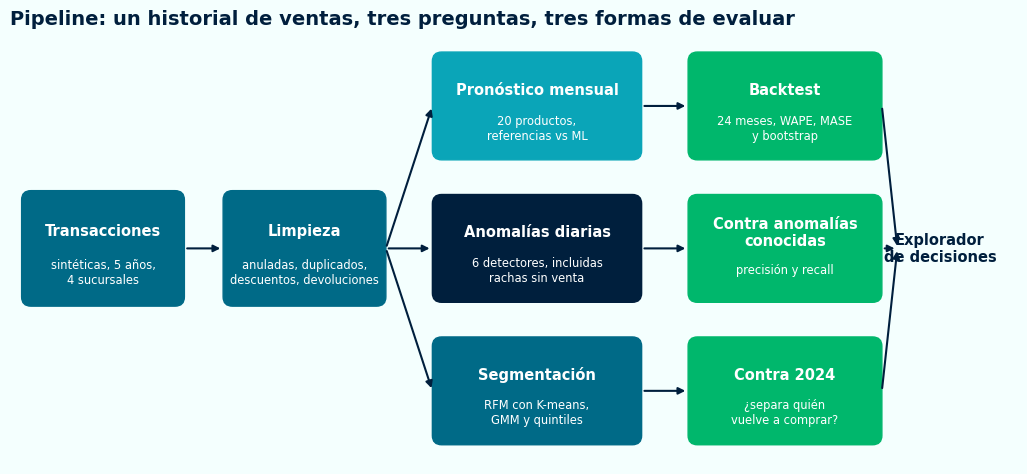

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5.6))
ax.set_xlim(0, 13); ax.set_ylim(0, 5.6); ax.axis('off')

def caja(x, y, w, h, titulo, sub, color):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05,rounding_size=0.12",
                                facecolor=color, edgecolor=color))
    ax.text(x + w / 2, y + h * 0.66, titulo, ha='center', va='center', color='white', fontsize=10.5, fontweight='bold')
    ax.text(x + w / 2, y + h * 0.28, sub, ha='center', va='center', color='white', fontsize=8.3)

def flecha(x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="-|>", color=C_DARK, lw=1.5))

caja(0.2, 2.1, 2.0, 1.4, "Transacciones", "sintéticas, 5 años,\n4 sucursales", C_WRONG)
caja(2.8, 2.1, 2.0, 1.4, "Limpieza", "anuladas, duplicados,\ndescuentos, devoluciones", C_WRONG)
caja(5.5, 4.0, 2.6, 1.3, "Pronóstico mensual", "20 productos,\nreferencias vs ML", C_TEAL)
caja(5.5, 2.15, 2.6, 1.3, "Anomalías diarias", "6 detectores, incluidas\nrachas sin venta", C_DARK)
caja(5.5, 0.3, 2.6, 1.3, "Segmentación", "RFM con K-means,\nGMM y quintiles", C_WRONG)
caja(8.8, 4.0, 2.4, 1.3, "Backtest", "24 meses, WAPE, MASE\ny bootstrap", C_RIGHT)
caja(8.8, 2.15, 2.4, 1.3, "Contra anomalías\nconocidas", "precisión y recall", C_RIGHT)
caja(8.8, 0.3, 2.4, 1.3, "Contra 2024", "¿separa quién\nvuelve a comprar?", C_RIGHT)
flecha(2.25, 2.8, 2.75, 2.8)
for y in [4.65, 2.8, 0.95]:
    flecha(4.85, 2.8, 5.45, y)
    flecha(8.15, y, 8.75, y)
ax.text(12.0, 2.8, "Explorador\nde decisiones", ha='center', va='center', color=C_DARK, fontsize=10.5, fontweight='bold')
for y in [4.65, 2.8, 0.95]:
    flecha(11.25, y, 11.45, 2.8)
ax.set_title("Pipeline: un historial de ventas, tres preguntas, tres formas de evaluar", loc='left')
plt.show()

## 1. Obtención de los datos

> **Nota sobre el dataset sintético.** Los datos de este notebook son sintéticos. Los datos reales del proyecto son información confidencial del negocio y no se pueden compartir. El dataset sintético se construyó para conservar la distribución, el volumen y, en la medida de lo posible, el realismo del conjunto original: la estacionalidad semanal y anual, la caída por la pandemia, la apertura tardía de una sucursal, la concentración de ventas en pocos productos, la mezcla de clientes frecuentes y ocasionales, y la suciedad típica de un sistema de facturación. Ningún nombre, código ni identificador corresponde a un cliente, producto o documento real.

- El generador está en la celda de abajo, completo, para que cualquiera pueda revisar cómo se construyó cada patrón.
- Si el CSV ya existe en la carpeta `data/` del repositorio, se carga de ahí. Si no, se genera con la semilla fija y se guarda.
- Una ventaja que solo existe porque los datos son sintéticos: se conocen las anomalías que se inyectaron y el tipo real de cada cliente. Esas etiquetas se guardan **aparte** y ningún modelo las ve, solo se usan al final para evaluar.

In [ ]:
F_SEMANA = np.array([1.10, 1.00, 1.00, 1.05, 1.15, 0.70])          # lunes a sábado
F_MES    = np.array([0.85, 0.80, 0.95, 0.95, 1.00, 1.00, 1.05, 1.05, 1.00, 1.00, 1.10, 1.25])
PESOS_SUC     = np.array([0.33, 0.20, 0.32, 0.15])
APERTURA_SUC4 = "2021-07-01"
CATEGORIAS    = ['Lubricantes', 'Filtros', 'Frenos', 'Suspensión', 'Eléctrico', 'Accesorios']
PRECIO_CAT    = np.array([45, 30, 110, 220, 85, 35], dtype=float)
CANT_CAT      = np.array([4.0, 2.0, 1.5, 1.3, 1.2, 1.5])
N_SKU         = 3000
SEGMENTOS = [
    # nombre, clientes, prob. de existir desde el inicio, vida media en días hábiles, tasa diaria,
    # líneas por ticket, multiplicador de cantidad, descuento, preferencia por lubricantes y filtros
    dict(nombre='Talleres y flotas', n=600,   p0=0.7, vida=1600, tasa=0.06,  lineas=2.5, mult=3.0, desc=0.10, boost=(2.5, 2.0)),
    dict(nombre='Recurrentes',       n=5000,  p0=0.3, vida=700,  tasa=0.006, lineas=1.6, mult=1.2, desc=0.03, boost=(1.3, 1.3)),
    dict(nombre='Ocasionales',       n=12000, p0=0.0, vida=90,   tasa=None,  lineas=1.3, mult=1.0, desc=0.00, boost=(1.0, 1.0)),
]

def generar_datos_sinteticos(seed=SEED):
    rng = np.random.default_rng(seed)

    # ── Calendario: lunes a sábado, sin tres feriados genéricos ──
    dias = pd.bdate_range(FECHA_INICIO, FECHA_FIN, freq='C', weekmask='Mon Tue Wed Thu Fri Sat')
    feriado = (((dias.month == 1) & (dias.day == 1)) | ((dias.month == 5) & (dias.day == 1))
               | ((dias.month == 12) & (dias.day == 25)))
    dias = dias[~np.asarray(feriado)]
    n_dias = len(dias)
    dow = np.asarray(dias.dayofweek)
    anios = np.asarray((dias - dias[0]).days) / 365.25
    f_pand = np.ones(n_dias)
    f_pand[np.asarray((dias >= '2020-03-16') & (dias <= '2020-05-31'))] = 0.15
    f_pand[np.asarray((dias >= '2020-06-01') & (dias <= '2020-12-31'))] = 0.55
    f_pand[np.asarray((dias >= '2021-01-01') & (dias <= '2021-03-31'))] = 0.75
    intensidad = F_SEMANA[dow] * F_MES[np.asarray(dias.month) - 1] * (1 + 0.04 * anios) * f_pand
    cum = np.concatenate([[0.0], np.cumsum(intensidad)])

    # ── Clientes: tipo, ventana de actividad y número de compras ──
    seg_cli, ini_cli, fin_cli, ntk_cli = [], [], [], []
    for s, p in enumerate(SEGMENTOS):
        n = p['n']
        ini = np.where(rng.random(n) < p['p0'], 0, rng.integers(0, n_dias, n))
        fin = np.minimum(ini + np.maximum(1, rng.exponential(p['vida'], n).astype(int)), n_dias)
        if p['tasa'] is None:
            ntk = 1 + rng.poisson(0.4, n)
        else:
            ntk = rng.poisson(rng.gamma(2.0, p['tasa'] / 2.0, n) * (cum[fin] - cum[ini]))
        seg_cli.append(np.full(n, s)); ini_cli.append(ini); fin_cli.append(fin); ntk_cli.append(ntk)
    seg_cli, ini_cli, fin_cli, ntk_cli = map(np.concatenate, (seg_cli, ini_cli, fin_cli, ntk_cli))
    n_cli = len(seg_cli)
    casa = rng.choice(4, n_cli, p=PESOS_SUC) + 1

    # ── Tickets: la fecha sigue la intensidad del negocio dentro de la ventana de cada cliente ──
    cli_t = np.repeat(np.arange(n_cli), ntk_cli)
    lo, hi = cum[ini_cli][cli_t], cum[fin_cli][cli_t]
    u = lo + rng.random(len(cli_t)) * (hi - lo)
    d_t = np.clip(np.searchsorted(cum, u, side='right') - 1, ini_cli[cli_t], fin_cli[cli_t] - 1)
    n_t = len(cli_t)
    suc_t = np.where(rng.random(n_t) < 0.85, casa[cli_t], rng.choice(4, n_t, p=PESOS_SUC) + 1)
    suc_t[(suc_t == 4) & np.asarray(dias[d_t] < pd.Timestamp(APERTURA_SUC4))] = 3
    orden = np.lexsort((suc_t, d_t))
    cli_t, d_t, suc_t = cli_t[orden], d_t[orden], suc_t[orden]
    tk = pd.DataFrame({'suc': suc_t})
    num = tk.groupby('suc').cumcount().values + 1
    doc_t = np.array([f"S{s}-{k:06d}" for s, k in zip(suc_t, num)])
    anulado_t = rng.random(n_t) < 0.015

    # ── Productos: popularidad tipo Zipf, categoría y precio de lista ──
    cat_sku = np.concatenate([np.tile([0, 1], 6), rng.choice(6, N_SKU - 12, p=[0.10, 0.15, 0.20, 0.20, 0.15, 0.20])])
    pop = 1.0 / np.arange(1, N_SKU + 1) ** 0.9
    p_sku = []
    for p in SEGMENTOS:
        b = np.ones(6); b[0], b[1] = p['boost']
        w = pop * b[cat_sku]
        p_sku.append(w / w.sum())
    precio_lista = PRECIO_CAT[cat_sku] * rng.lognormal(0, 0.35, N_SKU)
    codigos = np.array([f"SKU-{i + 1:05d}" for i in range(N_SKU)])

    # ── Líneas de cada ticket ──
    seg_t = seg_cli[cli_t]
    lin_media = np.array([p['lineas'] for p in SEGMENTOS])[seg_t]
    n_lin = 1 + rng.poisson(lin_media - 1)
    t_l = np.repeat(np.arange(n_t), n_lin)
    linea = np.arange(len(t_l)) - np.repeat(np.cumsum(n_lin) - n_lin, n_lin) + 1
    seg_l = seg_t[t_l]
    sku = np.empty(len(t_l), dtype=int)
    for s in range(len(SEGMENTOS)):
        m = seg_l == s
        sku[m] = rng.choice(N_SKU, m.sum(), p=p_sku[s])
    mult = np.array([p['mult'] for p in SEGMENTOS])[seg_l]
    desc = np.array([p['desc'] for p in SEGMENTOS])[seg_l]
    d_l = d_t[t_l]
    cant = 1 + rng.poisson(np.maximum(CANT_CAT[cat_sku[sku]] * mult - 1, 0))
    precio = precio_lista[sku] * 1.05 ** anios[d_l] * (1 - desc) * (1 + rng.normal(0, 0.02, len(t_l)))
    lineas = pd.DataFrame({
        'd': d_l, 'Sucursal': suc_t[t_l], 'Documento': doc_t[t_l], 'Linea': linea,
        'Cliente': np.array([f"CLI-{c + 1:05d}" for c in range(n_cli)])[cli_t[t_l]],
        'Codigo_Producto': codigos[sku], 'Categoria': np.array(CATEGORIAS)[cat_sku[sku]],
        'Cantidad': cant, 'Valor_Venta': np.round(cant * precio, 2),
        'Anulado': np.where(anulado_t[t_l], 'S', 'N'),
    })

    # ── Suciedad típica de un sistema de facturación ──
    extra = []
    for codigo, cat, frac, lo_p, hi_p in [('DCTO', 'Descuento', 0.03, -50, -5), ('TERCERO', 'Servicio de terceros', 0.02, 30, 300)]:
        sel = rng.choice(n_t, int(frac * n_t), replace=False)
        extra.append(pd.DataFrame({
            'd': d_t[sel], 'Sucursal': suc_t[sel], 'Documento': doc_t[sel], 'Linea': 99,
            'Cliente': np.array([f"CLI-{c + 1:05d}" for c in cli_t[sel]]), 'Codigo_Producto': codigo,
            'Categoria': cat, 'Cantidad': 1, 'Valor_Venta': np.round(rng.uniform(lo_p, hi_p, len(sel)), 2),
            'Anulado': np.where(anulado_t[sel], 'S', 'N')}))
    validas = lineas.index[lineas['Anulado'] == 'N']
    dev = lineas.loc[rng.choice(validas, int(0.005 * len(lineas)), replace=False)].copy()
    dev['d'] = np.minimum(dev['d'] + rng.integers(1, 20, len(dev)), n_dias - 1)
    dev['Documento'] = dev['Documento'] + '-D'
    dev['Cantidad'] = -dev['Cantidad']; dev['Valor_Venta'] = -dev['Valor_Venta']
    lineas = pd.concat([lineas] + extra + [dev], ignore_index=True)

    # ── Anomalías inyectadas en los 10 productos con más unidades esperadas ──
    etiquetas = []
    elegibles = np.where(np.asarray(dias >= '2020-07-01'))[0][:-10]
    talleres = np.where(seg_cli == 0)[0]
    n_evento = 0
    peso_unidades = pop * CANT_CAT[cat_sku] * np.where(cat_sku == 0, 2.5, np.where(cat_sku == 1, 2.0, 1.0))
    for k in np.argsort(-peso_unidades)[:10]:                # los 10 con más unidades esperadas
        codigo = codigos[k]
        es_k = lineas['Codigo_Producto'] == codigo
        tipico = lineas.loc[es_k & (lineas['Cantidad'] > 0), 'Cantidad'].sum() / n_dias
        ocupados = set()
        for _ in range(2):                                   # quiebre de stock: días seguidos sin venta
            ini = int(rng.choice(elegibles)); dur = int(rng.integers(4, 8))
            ventana = list(range(ini, min(ini + dur, n_dias)))
            lineas = lineas[~((lineas['Codigo_Producto'] == codigo) & lineas['d'].isin(ventana))]
            ocupados.update(ventana)
            etiquetas += [(codigo, dias[v], 'quiebre_stock') for v in ventana]
        libres = np.array([v for v in elegibles if v not in ocupados])
        dias_pico = rng.choice(libres, 6, replace=False)
        for j, v in enumerate(dias_pico):                    # pedidos atípicos: 3 evidentes y 3 moderados
            c = int(rng.choice(talleres)); n_evento += 1
            suc_c = 3 if (casa[c] == 4 and dias[v] < pd.Timestamp(APERTURA_SUC4)) else int(casa[c])
            evidente = j < 3
            q = int(max(5, round(tipico * (rng.uniform(6, 12) if evidente else rng.uniform(2.5, 4)))))
            lineas = pd.concat([lineas, pd.DataFrame([{
                'd': int(v), 'Sucursal': suc_c, 'Documento': f"S{suc_c}-A{n_evento:05d}", 'Linea': 1,
                'Cliente': f"CLI-{c + 1:05d}", 'Codigo_Producto': codigo, 'Categoria': CATEGORIAS[cat_sku[k]],
                'Cantidad': q, 'Valor_Venta': round(q * precio_lista[k] * 1.05 ** anios[v] * 0.9, 2), 'Anulado': 'N'}])],
                ignore_index=True)
            etiquetas.append((codigo, dias[v], 'pedido_atipico' if evidente else 'pedido_moderado'))
        ocupados.update(dias_pico.tolist())
        cand = lineas.index[(lineas['Codigo_Producto'] == codigo) & (lineas['Anulado'] == 'N')
                            & (lineas['Cantidad'] > 0) & ~lineas['d'].isin(list(ocupados))
                            & (lineas['d'] >= elegibles[0])]
        for i in rng.choice(cand, 2, replace=False):         # error de captura: cantidad multiplicada por 100
            lineas.loc[i, 'Cantidad'] *= 100
            lineas.loc[i, 'Valor_Venta'] = round(lineas.loc[i, 'Valor_Venta'] * 100, 2)
            etiquetas.append((codigo, dias[int(lineas.loc[i, 'd'])], 'error_captura'))

    dup = lineas.sample(frac=0.002, random_state=seed)
    lineas = pd.concat([lineas, dup], ignore_index=True)
    lineas['Fecha_Emision'] = dias[lineas['d'].values]
    lineas = (lineas.drop(columns='d').sort_values(['Fecha_Emision', 'Documento', 'Linea'])
              [['Fecha_Emision', 'Sucursal', 'Documento', 'Linea', 'Cliente', 'Codigo_Producto',
                'Categoria', 'Cantidad', 'Valor_Venta', 'Anulado']].reset_index(drop=True))
    etiquetas = pd.DataFrame(etiquetas, columns=['Codigo_Producto', 'Fecha_Emision', 'Tipo']).drop_duplicates(['Codigo_Producto', 'Fecha_Emision'])
    segmentos = pd.DataFrame({'Cliente': [f"CLI-{c + 1:05d}" for c in range(n_cli)],
                              'Segmento_real': np.array([p['nombre'] for p in SEGMENTOS])[seg_cli]})
    return lineas, etiquetas, segmentos

def cargar_o_generar():
    lector = dict(parse_dates=['Fecha_Emision'], dtype={'Codigo_Producto': str, 'Documento': str, 'Cliente': str})
    for base in ['data/', URL_REPO_DATOS]:
        try:
            v = pd.read_csv(base + 'ventas_sinteticas.csv', **lector)
            e = pd.read_csv(base + 'anomalias_inyectadas.csv', parse_dates=['Fecha_Emision'], dtype={'Codigo_Producto': str})
            s = pd.read_csv(base + 'segmento_real_clientes.csv', dtype={'Cliente': str})
            print("Datos cargados desde", base)
            return v, e, s
        except Exception:
            pass
    print("No se encontró el CSV, se genera el dataset sintético con semilla", SEED)
    v, e, s = generar_datos_sinteticos(SEED)
    os.makedirs('data', exist_ok=True)
    v.to_csv(RUTA_DATOS, index=False); e.to_csv(RUTA_ETIQUETAS, index=False); s.to_csv(RUTA_SEGMENTOS, index=False)
    print("Guardado en data/")
    return v, e, s

crudo, ETIQUETAS_ANOMALIAS, SEGMENTO_REAL = cargar_o_generar()
if 'pedido_moderado' not in set(ETIQUETAS_ANOMALIAS['Tipo']):
    print("AVISO: los datos cargados son de una versión anterior del generador, sin pedidos moderados. "
          "Borra la carpeta data/ y vuelve a correr para regenerarlos.")
print(f"{len(crudo):,} líneas  |  {crudo['Documento'].nunique():,} documentos  |  {crudo['Cliente'].nunique():,} clientes  |  "
      f"{crudo['Codigo_Producto'].nunique():,} códigos  |  {crudo['Fecha_Emision'].min().date()} a {crudo['Fecha_Emision'].max().date()}")
crudo.head()

No se encontró el CSV, se genera el dataset sintético con semilla 42
Guardado en data/
126,150 líneas  |  63,044 documentos  |  15,961 clientes  |  2,999 códigos  |  2020-01-02 a 2024-12-31


,Fecha_Emision,Sucursal,Documento,Linea,Cliente,Codigo_Producto,Categoria,Cantidad,Valor_Venta,Anulado
0,2020-01-02,1,S1-000001,1,CLI-00197,SKU-00009,Lubricantes,11,598.80,N
1,2020-01-02,1,S1-000001,2,CLI-00197,SKU-00075,Filtros,4,113.41,N
2,2020-01-02,1,S1-000001,3,CLI-00197,SKU-00001,Lubricantes,12,860.98,N
3,2020-01-02,1,S1-000002,1,CLI-00199,SKU-00004,Filtros,5,215.74,N
4,2020-01-02,1,S1-000003,1,CLI-00199,SKU-00528,Lubricantes,10,319.48,N


## 2. Explicación de los datos

Cada fila es una línea de un documento de venta:

- **Fecha_Emision** y **Sucursal**: cuándo y en cuál de las cuatro sucursales se vendió.
- **Documento** y **Linea**: el ticket y la posición del producto dentro del ticket. Un ticket puede tener varias líneas.
- **Cliente**: identificador ficticio del cliente.
- **Codigo_Producto** y **Categoria**: el producto vendido. Además de productos, aparecen códigos que no son productos, como descuentos y servicios de terceros.
- **Cantidad** y **Valor_Venta**: unidades y monto de la línea. Las devoluciones aparecen como cantidades negativas.
- **Anulado**: `S` si el documento se anuló después de emitirse.

La celda siguiente cuantifica cada problema de calidad antes de limpiarlo, para que la limpieza sea una decisión informada y no un paso automático.

In [ ]:
no_producto = ~crudo['Codigo_Producto'].str.startswith('SKU-')
calidad = pd.Series({
    'Líneas totales': len(crudo),
    'Filas duplicadas exactas': int(crudo.duplicated().sum()),
    'Líneas de documentos anulados': int((crudo['Anulado'] == 'S').sum()),
    'Líneas que no son producto': int(no_producto.sum()),
    'Devoluciones, cantidad negativa': int((crudo['Cantidad'] < 0).sum()),
    'Valores nulos': int(crudo.isna().sum().sum()),
})
print(calidad.to_string())
print("\nCódigos que no son producto:", crudo.loc[no_producto, 'Codigo_Producto'].value_counts().to_dict())

Líneas totales                     126150
Filas duplicadas exactas              252
Líneas de documentos anulados        1821
Líneas que no son producto           3128
Devoluciones, cantidad negativa       609
Valores nulos                           0

Códigos que no son producto: {'DCTO': 1876, 'TERCERO': 1252}


### Limpieza

Cada regla se aplica por una razón de negocio, no por costumbre:

- **Duplicados exactos** se eliminan porque son la misma línea exportada dos veces.
- **Documentos anulados** se eliminan porque esa venta no ocurrió.
- **Descuentos y servicios de terceros** se eliminan de la demanda porque no son unidades de un producto.
- **Devoluciones** se separan: no son demanda, pero sí restan del valor que aportó cada cliente.

In [ ]:
limpio = crudo.drop_duplicates()
limpio = limpio[limpio['Anulado'] == 'N']
limpio = limpio[limpio['Codigo_Producto'].str.startswith('SKU-')].copy()

VENTAS = limpio[limpio['Cantidad'] > 0].copy()          # demanda: lo que se vendió
MOVIMIENTOS = limpio.copy()                              # ventas y devoluciones: lo que aportó cada cliente

CALENDARIO = pd.DatetimeIndex(np.sort(VENTAS['Fecha_Emision'].unique()))
print(f"Ventas válidas: {len(VENTAS):,} líneas  |  devoluciones: {(limpio['Cantidad'] < 0).sum():,}  |  días con operación: {len(CALENDARIO):,}")

Ventas válidas: 120,397 líneas  |  devoluciones: 608  |  días con operación: 1,554


## 3. Análisis exploratorio

Cuatro preguntas, cada una condiciona una decisión posterior.

- **¿Cómo evoluciona la venta?** Si hay estacionalidad y eventos como la pandemia, el pronóstico necesita variables de calendario y el detector de anomalías tiene que distinguir un evento de un error.
- **¿Qué tan concentrada está la venta?** Si pocos productos explican casi todo, tiene sentido pronosticarlos uno por uno y agrupar el resto.
- **¿Qué pasa con cada día de la semana y cada mes?** Es la estructura que cualquier modelo debería reproducir.
- **¿A qué nivel pronosticar?** Lo resuelve la primera decisión, más abajo.

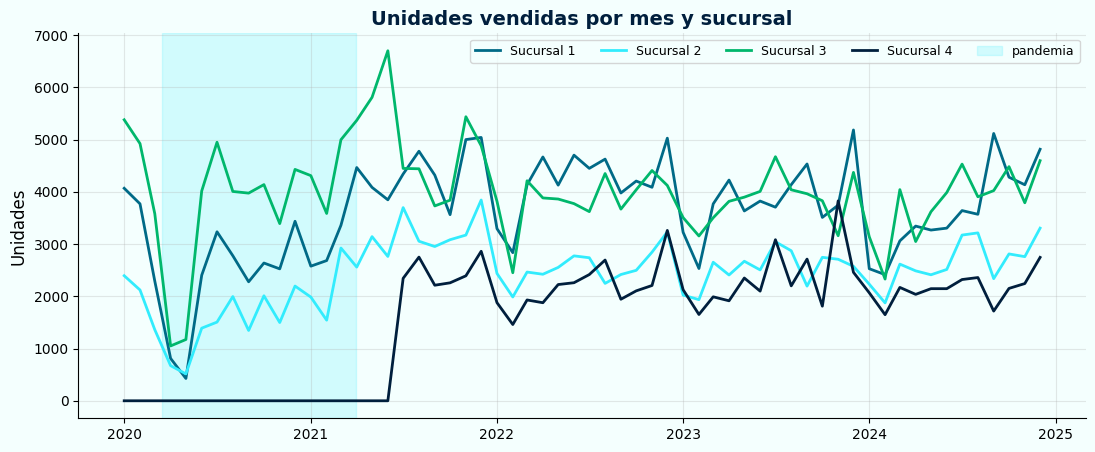

In [ ]:
mensual_suc = (VENTAS.groupby([pd.Grouper(key='Fecha_Emision', freq='MS'), 'Sucursal'])['Cantidad'].sum()
               .unstack(fill_value=0))
fig, ax = plt.subplots(figsize=(13, 5))
for s, c in zip(mensual_suc.columns, brand_colors(len(mensual_suc.columns))):
    ax.plot(mensual_suc.index, mensual_suc[s], color=c, linewidth=2, label=f'Sucursal {s}')
ax.axvspan(pd.Timestamp('2020-03-16'), pd.Timestamp('2021-03-31'), color=C_ACCENT, alpha=0.18, label='pandemia')
ax.set_title('Unidades vendidas por mes y sucursal')
ax.set_ylabel('Unidades'); ax.legend(ncol=5, fontsize=9); ax.grid(True, alpha=0.3)
plt.show()

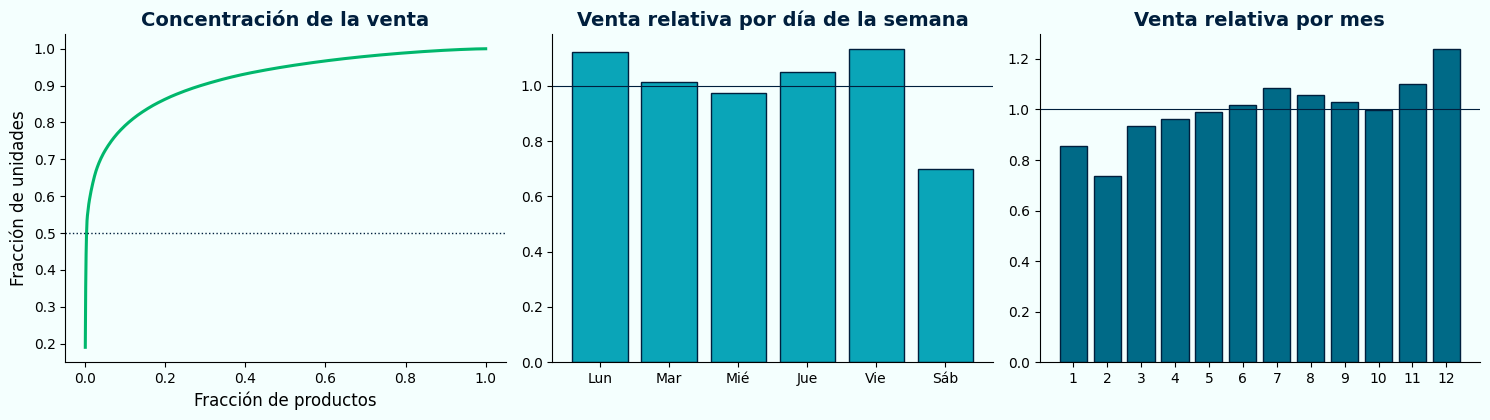

11 productos de 2,997 explican la mitad de las unidades vendidas.


In [ ]:
por_producto = VENTAS.groupby('Codigo_Producto')['Cantidad'].sum().sort_values(ascending=False)
acum = por_producto.cumsum() / por_producto.sum()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
axes[0].plot(np.arange(1, len(acum) + 1) / len(acum), acum.values, color=C_RIGHT, linewidth=2.2)
axes[0].axhline(0.5, color=C_DARK, linestyle=':', linewidth=1)
axes[0].set_title('Concentración de la venta'); axes[0].set_xlabel('Fracción de productos'); axes[0].set_ylabel('Fracción de unidades')
diario_total = VENTAS.groupby('Fecha_Emision')['Cantidad'].sum()
normal = diario_total[diario_total.index >= '2021-04-01']
dia = normal.groupby(normal.index.dayofweek).mean(); dia = dia / dia.mean()
axes[1].bar(['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb'], dia.values, color=C_TEAL, edgecolor=C_DARK)
axes[1].axhline(1, color=C_DARK, linewidth=0.8); axes[1].set_title('Venta relativa por día de la semana')
mes = normal.groupby(normal.index.month).mean(); mes = mes / mes.mean()
axes[2].bar(range(1, 13), mes.values, color=C_WRONG, edgecolor=C_DARK)
axes[2].axhline(1, color=C_DARK, linewidth=0.8); axes[2].set_title('Venta relativa por mes'); axes[2].set_xticks(range(1, 13))
plt.tight_layout(); plt.show()
k50 = int((acum < 0.5).sum()) + 1
print(f"{k50} productos de {len(acum):,} explican la mitad de las unidades vendidas.")

## 4. Lo que cambió respecto a la primera versión de este análisis

La primera versión de este proyecto llegó a resultados que se veían bien, pero varios no resistían una revisión. Se documentan porque son los errores más comunes en proyectos de este tipo.

- **Meses barajados.** El pronóstico dividía los datos con `train_test_split`, que por defecto mezcla las filas. El modelo se entrenaba con meses posteriores a los que después "pronosticaba".
- **La fecha como variable.** La fecha entraba al modelo codificada en one-hot. Cada mes de prueba era una columna que el modelo nunca había visto, así que esa variable no aportaba nada al pronóstico y sí agregaba ruido.
- **Preprocesamiento con el test.** El escalador se ajustaba con entrenamiento y prueba juntos.
- **Rezagos rellenados con cero.** Los primeros meses sin historia se llenaban con ceros, como si en esos meses no se hubiera vendido nada.
- **Un baseline que ve el futuro.** La referencia de comparación era el promedio del propio periodo de prueba.
- **Un modelo que nunca se entrenó.** La red LSTM de la comparación estaba vacía, y su resultado era una copia del de LightGBM.
- **Anomalías sin verdad contra la cual medir.** Los detectores se calificaban con un índice cuyo valor objetivo se había fijado de antemano, sin saber cuáles días eran realmente anómalos.
- **Un valor de venta sin relación con el producto.** El generador de datos asignaba el monto al azar, lo que vaciaba de sentido el valor monetario de la segmentación.

Todo lo que sigue corrige estos puntos, y el checklist metodológico del final lo verifica con código.

### Y lo que cambió después de la primera corrida de esta versión

Corregir los errores anteriores no bastó. La primera corrida de esta versión, ya sin fugas, dejó ver cinco huecos más, y también se documentan:

- **Ningún detector encontraba un quiebre de stock.** La venta diaria de un producto es irregular y un día sin venta es normal. Lo anómalo es una **racha** de días sin venta, y ningún método evaluaba rachas. Se agregó un detector que mide qué tan improbable es cada racha.
- **Los pedidos atípicos eran demasiado evidentes.** Todos los métodos los detectaban. Se agregaron pedidos moderados, de 2.5 a 4 veces lo normal, que sí separan a un buen detector de uno malo.
- **Isolation Forest competía con desventaja.** Recibía niveles de venta y no desviaciones de lo esperado, así que la comparación no era justa. Ahora recibe las dos cosas.
- **Las métricas del pronóstico coincidían porque todos los productos vendían mucho.** El problema del MAPE aparece con productos de volumen medio, así que ahora entran al backtest.
- **Las reglas RFM desempataban al azar.** Con muchos clientes de una sola compra, el ranking asignaba quintiles distintos a clientes idénticos. Ahora la frecuencia usa cortes fijos.

## 5. Pronóstico de ventas

### Decisión: ¿pronosticar por día o por mes?

**¿Pronosticar por día o por mes?**

El pronóstico diario da más detalle, pero para la mayoría de los productos un día típico es cero o casi cero, y un modelo que aprende a decir "cero" parece preciso sin servir para nada. El pronóstico mensual pierde detalle, pero la señal se vuelve estable y coincide con la frecuencia con la que el negocio decide compras de inventario. Este notebook pronostica **por mes**. La celda siguiente mide qué tan intermitente es cada nivel, para los 10 productos de alto volumen y para 10 de volumen medio.

Explora esta decisión en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/prediccion-ventas-segmentacion-anomalias/#explorador-nivel_agregacion)


In [ ]:
pre = VENTAS[VENTAS['Fecha_Emision'] < INICIO_BACKTEST]
RANKING_PREVIO = pre.groupby('Codigo_Producto')['Cantidad'].sum().sort_values(ascending=False).index
TOP = RANKING_PREVIO[:N_PRODUCTOS].tolist()
MEDIOS = RANKING_PREVIO[RANGO_MEDIOS[0]:RANGO_MEDIOS[1]].tolist()
PRODUCTOS_PRON = TOP + MEDIOS
GRUPO = {**{p: 'Alto volumen' for p in TOP}, **{p: 'Volumen medio' for p in MEDIOS}}
print("Elegidos solo con ventas previas a", INICIO_BACKTEST)
print("  Alto volumen: ", TOP)
print("  Volumen medio:", MEDIOS)

def serie_diaria(productos):
    return (VENTAS[VENTAS['Codigo_Producto'].isin(productos)]
            .groupby(['Fecha_Emision', 'Codigo_Producto'])['Cantidad'].sum().unstack()
            .reindex(index=CALENDARIO, columns=productos).fillna(0))

diario_top = serie_diaria(TOP)
diario_medios = serie_diaria(MEDIOS)
MESES = pd.date_range(FECHA_INICIO, FECHA_FIN, freq='MS')
MENSUAL = serie_diaria(PRODUCTOS_PRON).resample('MS').sum().reindex(MESES).fillna(0)

cv = lambda df: float((df.std() / df.mean()).mean())
AGREGACION = pd.DataFrame({
    'Días o meses sin venta, alto volumen': [(diario_top == 0).mean().mean(), (MENSUAL[TOP] == 0).mean().mean()],
    'Días o meses sin venta, volumen medio': [(diario_medios == 0).mean().mean(), (MENSUAL[MEDIOS] == 0).mean().mean()],
    'Coef. de variación, alto volumen': [cv(diario_top), cv(MENSUAL[TOP])],
    'Coef. de variación, volumen medio': [cv(diario_medios), cv(MENSUAL[MEDIOS])],
}, index=['Diario', 'Mensual']).T
AGREGACION.round(3)

Elegidos solo con ventas previas a 2023-01-01
  Alto volumen:  ['SKU-00001', 'SKU-00003', 'SKU-00005', 'SKU-00002', 'SKU-00007', 'SKU-00009', 'SKU-00004', 'SKU-00011', 'SKU-00006', 'SKU-00008']
  Volumen medio: ['SKU-00054', 'SKU-00048', 'SKU-00016', 'SKU-00064', 'SKU-00065', 'SKU-00171', 'SKU-00026', 'SKU-00183', 'SKU-00025', 'SKU-00201']


,Diario,Mensual
"Días o meses sin venta, alto volumen",0.209,0.000
"Días o meses sin venta, volumen medio",0.839,0.052
"Coef. de variación, alto volumen",1.912,0.443
"Coef. de variación, volumen medio",2.974,0.634


### Variables del pronóstico

- **Rezagos de 1, 2, 3, 6 y 12 meses** y **promedios móviles de 3 y 12 meses**. Todos se calculan con meses anteriores al que se pronostica, nunca con el mismo mes.
- **Mes del año en forma cíclica**, con seno y coseno, para que diciembre y enero queden cerca.
- **Días hábiles del mes**, que se conocen con anticipación.
- **Indicador de pandemia**, que marca un periodo histórico excepcional para que el modelo no lo confunda con la tendencia.
- Los meses sin historia suficiente para calcular los rezagos se **descartan**, no se rellenan con ceros.

In [ ]:
DIAS_HABILES = pd.Series(1, index=CALENDARIO).resample('MS').sum().reindex(MESES).fillna(0)
FEATURES = [f'lag_{L}' for L in LAGS] + ['media_3', 'media_12', 'mes_sin', 'mes_cos', 'dias_habiles', 'pandemia']
FEATURES_ESCALA = [f'lag_{L}' for L in LAGS] + ['media_3', 'media_12']   # las que se dividen por la escala en el modelo global

def features_mensuales(s):
    d = pd.DataFrame({'y': s})
    for L in LAGS:
        d[f'lag_{L}'] = s.shift(L)
    d['media_3'] = s.shift(1).rolling(3).mean()
    d['media_12'] = s.shift(1).rolling(12).mean()
    m = d.index.month
    d['mes_sin'] = np.sin(2 * np.pi * m / 12)
    d['mes_cos'] = np.cos(2 * np.pi * m / 12)
    d['dias_habiles'] = DIAS_HABILES.reindex(d.index).values
    d['pandemia'] = ((d.index >= '2020-03-01') & (d.index <= '2021-03-01')).astype(int)
    return d.dropna()

PANEL = pd.concat({p: features_mensuales(MENSUAL[p]) for p in PRODUCTOS_PRON}, names=['producto', 'mes']).reset_index()
PANEL['grupo'] = PANEL['producto'].map(GRUPO)
print(f"Panel: {len(PANEL)} filas, {PANEL['mes'].min().date()} a {PANEL['mes'].max().date()}, {PANEL['producto'].nunique()} productos")
PANEL.head()

Panel: 960 filas, 2021-01-01 a 2024-12-01, 20 productos


,producto,mes,y,lag_1,lag_2,lag_3,lag_6,lag_12,media_3,media_12,mes_sin,mes_cos,dias_habiles,pandemia,grupo
0,SKU-00001,2021-01-01,1623.0,1708.0,1573.0,1765.0,1678.0,2236.0,1682.000000,1487.333333,0.500000,8.660254e-01,25,1,Alto volumen
1,SKU-00001,2021-02-01,1524.0,1623.0,1708.0,1573.0,1542.0,2165.0,1634.666667,1436.250000,0.866025,5.000000e-01,24,1,Alto volumen
2,SKU-00001,2021-03-01,2242.0,1524.0,1623.0,1708.0,1471.0,1287.0,1618.333333,1382.833333,1.000000,6.123234e-17,27,1,Alto volumen
3,SKU-00001,2021-04-01,2495.0,2242.0,1524.0,1623.0,1765.0,489.0,1796.333333,1462.416667,0.866025,-5.000000e-01,26,0,Alto volumen
4,SKU-00001,2021-05-01,2343.0,2495.0,2242.0,1524.0,1573.0,356.0,2087.000000,1629.583333,0.500000,-8.660254e-01,25,0,Alto volumen


### Decisión: ¿un modelo por producto o un modelo global?

**¿Un modelo por producto o un modelo global para todos?**

Con 5 años de historia, cada producto tiene unos 48 meses utilizables, y al inicio del backtest solo 24. Un modelo por producto aprende de muy pocos ejemplos y puede sobreajustar. Un **modelo global** aprende de los 20 productos a la vez: para que las escalas no se mezclen, cada producto se divide entre su propio volumen promedio, calculado solo con su entrenamiento, y la predicción se multiplica de vuelta. Es la estrategia que dominó competencias de pronóstico con muchas series cortas, como la M5. Aquí se corren las dos opciones con los mismos tres algoritmos, y un bootstrap por meses dice si la diferencia entre ambas es real o cabe en el ruido.

**Modelos comparados:**

- **Referencias sin aprendizaje:** el mes anterior, el mismo mes del año anterior y el promedio de los últimos 3 meses. Si un modelo no les gana, su complejidad no se justifica.
- **Ridge**, regresión lineal regularizada.
- **Random Forest**, que era el mejor de la versión anterior.
- **LightGBM**, boosting de árboles, la opción más usada hoy en pronóstico tabular.

La red LSTM de la versión anterior no se incluye: con 24 a 48 observaciones por producto no hay datos para entrenarla, y la comparación anterior nunca la había entrenado.

Explora esta decisión en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/prediccion-ventas-segmentacion-anomalias/#explorador-modelo_global)


In [ ]:
def nuevo_modelo(nombre):
    if nombre == 'Ridge':
        return make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    if nombre == 'Random Forest':
        return RandomForestRegressor(n_estimators=200, min_samples_leaf=2, random_state=SEED, n_jobs=-1)
    if nombre == 'LightGBM':
        return LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=15, min_child_samples=5,
                             subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=SEED, verbose=-1)
    raise ValueError(nombre)

ALGORITMOS = ['Ridge', 'Random Forest', 'LightGBM']
BASELINES_PRON = {'Mes anterior': 'lag_1', 'Mismo mes año anterior': 'lag_12', 'Promedio 3 meses': 'media_3'}
ORIGENES = pd.date_range(INICIO_BACKTEST, FECHA_FIN, freq='MS')
LOG_PRONOSTICO = []

filas = []
for origen in ORIGENES:
    train = PANEL[PANEL['mes'] < origen]
    test = PANEL[PANEL['mes'] == origen]
    assert train['mes'].max() < origen and (test['mes'] == origen).all()

    for nombre, col in BASELINES_PRON.items():
        for _, r in test.iterrows():
            filas.append((origen, r['producto'], nombre, r['y'], r[col]))

    # Modelo global: un solo ajuste para todos los productos, con cada producto en su propia escala.
    escala = train.groupby('producto')['y'].mean().clip(lower=1.0)
    tr, te = train.copy(), test.copy()
    for d in (tr, te):
        f = d['producto'].map(escala).values
        d['y'] = d['y'] / f
        for c in FEATURES_ESCALA:
            d[c] = d[c] / f
    LOG_PRONOSTICO.append({'origen': origen, 'modo': 'global', 'max_mes_train': train['mes'].max(),
                           'escala_ok': bool(np.allclose(escala.values, train.groupby('producto')['y'].mean().clip(lower=1.0).values))})
    for alg in ALGORITMOS:
        m = nuevo_modelo(alg).fit(tr[FEATURES], tr['y'])
        pred = np.clip(m.predict(te[FEATURES]), 0, None) * te['producto'].map(escala).values
        for (_, r), p in zip(test.iterrows(), pred):
            filas.append((origen, r['producto'], f'{alg} global', r['y'], p))

    # Un modelo por producto: mismos algoritmos, cada uno con solo su historia.
    for prod in PRODUCTOS_PRON:
        trp, tep = train[train['producto'] == prod], test[test['producto'] == prod]
        LOG_PRONOSTICO.append({'origen': origen, 'modo': prod, 'max_mes_train': trp['mes'].max(), 'escala_ok': True})
        for alg in ALGORITMOS:
            m = nuevo_modelo(alg).fit(trp[FEATURES], trp['y'])
            p = float(np.clip(m.predict(tep[FEATURES]), 0, None)[0])
            filas.append((origen, prod, f'{alg} por producto', float(tep['y'].iloc[0]), p))

PRON = pd.DataFrame(filas, columns=['origen', 'producto', 'metodo', 'y', 'yhat'])
PRON['grupo'] = PRON['producto'].map(GRUPO)
print(f"{len(ORIGENES)} meses pronosticados × {len(PRODUCTOS_PRON)} productos × {PRON['metodo'].nunique()} métodos = {len(PRON)} pronósticos")

24 meses pronosticados × 20 productos × 9 métodos = 4320 pronósticos


### Decisión: ¿con qué métrica elegir el modelo?

**¿MAPE, WAPE o MASE?**

La versión anterior eligió el modelo con el **MAPE**, el error porcentual promedio. Tiene un problema conocido: cuando un producto vende poco en un mes, un error de pocas unidades se vuelve un porcentaje enorme, y esos meses pesan en el promedio tanto como los meses de mucha venta. El riesgo es que el MAPE elija al modelo que mejor le va a los productos chicos, no al que mejor le va al inventario.

- **WAPE** suma todos los errores absolutos y los divide entre todas las unidades vendidas. Pesa cada producto según lo que vende, que es como lo pesa el inventario.
- **MASE** divide el error de cada producto entre el error que habría tenido el pronóstico "mismo mes del año anterior" en su historia previa. Un MASE menor que 1 significa que el modelo mejora la referencia estacional.
- **Sesgo**: si el modelo tiende a pronosticar de más o de menos. Pronosticar de menos se traduce en faltantes, pronosticar de más en inventario inmovilizado.

Se reportan las tres, por separado para productos de alto volumen y de volumen medio, más la capa de negocio: **unidades faltantes y sobrantes** si se hubiera comprado exactamente lo pronosticado. Que las métricas coincidan o no es un resultado, no un supuesto.

Explora esta decisión en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/prediccion-ventas-segmentacion-anomalias/#explorador-metrica_pronostico)


In [ ]:
# Escala del MASE: error del pronóstico estacional en los 24 meses previos al backtest, sin tocar el backtest.
hist_mase = MENSUAL[MENSUAL.index < INICIO_BACKTEST]
ESCALA_MASE = (hist_mase - hist_mase.shift(12)).abs().iloc[12:].mean().clip(lower=1.0)

def metricas_pronostico(g):
    e = g['yhat'] - g['y']
    mase = (g.assign(ae=e.abs()).groupby('producto')['ae'].mean() / ESCALA_MASE.reindex(g['producto'].unique())).mean()
    pos = g['y'] > 0
    return pd.Series({
        'WAPE': e.abs().sum() / g['y'].sum(),
        'MASE': mase,
        'MAPE': (e[pos].abs() / g.loc[pos, 'y']).mean(),
        'Sesgo': e.sum() / g['y'].sum(),
        'Unidades faltantes': (-e).clip(lower=0).sum(),
        'Unidades sobrantes': e.clip(lower=0).sum(),
    })

def sumas_por_mes(metodo, datos=None):
    d = (PRON if datos is None else datos)
    d = d[d['metodo'] == metodo].assign(ae=lambda x: (x['yhat'] - x['y']).abs())
    return d.groupby('origen')[['ae', 'y']].sum().sort_index()

def bootstrap_wape(m1, m2, datos=None, n=N_BOOTSTRAP, bloque=3):
    """Remuestrea meses completos, en bloques de 3, y compara el WAPE de dos métodos en los mismos meses.
    Devuelve el intervalo del 95% de la diferencia m1 − m2 y la probabilidad de que m1 tenga menor error."""
    a, b = sumas_por_mes(m1, datos), sumas_por_mes(m2, datos)
    rng = np.random.default_rng(SEED)
    T = len(a); k = int(np.ceil(T / bloque)); dif = np.empty(n)
    for i in range(n):
        ii = ((rng.integers(0, T, k)[:, None] + np.arange(bloque)[None, :]).ravel()[:T]) % T
        dif[i] = a['ae'].values[ii].sum() / a['y'].values[ii].sum() - b['ae'].values[ii].sum() / b['y'].values[ii].sum()
    return np.percentile(dif, 2.5), np.percentile(dif, 97.5), float((dif < 0).mean())

MET_PRON = pd.DataFrame({m: metricas_pronostico(g) for m, g in PRON.groupby('metodo')}).T.sort_values('WAPE')
# La vara es la mejor referencia sin aprendizaje: es la comparación más exigente para cualquier modelo.
REFERENCIA = MET_PRON.loc[list(BASELINES_PRON)].sort_values('WAPE').index[0]
ref = PRON[PRON['metodo'] == REFERENCIA].set_index(['origen', 'producto'])['yhat']
gana, p_mejor = {}, {}
for m, g in PRON.groupby('metodo'):
    gg = g.set_index(['origen', 'producto'])
    err_m = (gg['yhat'] - gg['y']).abs().groupby(level='producto').sum()
    err_r = (ref - gg['y']).abs().groupby(level='producto').sum()
    gana[m] = int((err_m < err_r).sum())
    p_mejor[m] = np.nan if m == REFERENCIA else bootstrap_wape(m, REFERENCIA)[2]
MET_PRON['Productos donde mejora a la referencia'] = pd.Series(gana)
MET_PRON['P(WAPE menor que la referencia)'] = pd.Series(p_mejor)
MET_GRUPO = {gr: pd.DataFrame({m: metricas_pronostico(g) for m, g in PRON[PRON['grupo'] == gr].groupby('metodo')}).T
             for gr in ['Alto volumen', 'Volumen medio']}
print(f"Todos los productos. Referencia de comparación: {REFERENCIA}.")
MET_PRON.round({'WAPE': 3, 'MASE': 3, 'MAPE': 3, 'Sesgo': 3, 'Unidades faltantes': 0, 'Unidades sobrantes': 0,
                'P(WAPE menor que la referencia)': 2})

Todos los productos. Referencia de comparación: Mismo mes año anterior.


,WAPE,MASE,MAPE,Sesgo,Unidades faltantes,Unidades sobrantes,Productos donde mejora a la referencia,P(WAPE menor que la referencia)
Random Forest global,0.213,0.650,0.501,0.045,13033.0,19927.0,18,0.98
Random Forest por producto,0.220,0.695,0.506,0.024,15167.0,18886.0,18,0.98
Ridge global,0.224,0.654,0.478,0.010,16565.0,18073.0,17,0.93
LightGBM global,0.240,0.708,0.527,0.056,14223.0,22932.0,17,0.70
Mismo mes año anterior,0.251,0.860,0.650,0.009,18688.0,20024.0,0,NaN
Ridge por producto,0.251,0.775,0.547,0.029,17156.0,21567.0,14,0.50
LightGBM por producto,0.251,0.793,0.571,0.026,17411.0,21385.0,15,0.48
Promedio 3 meses,0.254,0.741,0.520,-0.004,19903.0,19311.0,15,0.47
Mes anterior,0.300,0.873,0.609,-0.000,23228.0,23151.0,11,0.02


- La referencia de comparación es la **mejor de las tres referencias sin aprendizaje** en esta corrida. Es la vara más exigente: un modelo que le gana a la mejor alternativa simple le gana a todas.
- `P(WAPE menor que la referencia)` resume el bootstrap: 50% significa que, con 24 meses, el método no se distingue de la referencia. Solo por arriba de 95% la mejora está demostrada con esta muestra.
- Un modelo puede ganar en la tabla y aun así no tener una ventaja demostrada. El notebook no la vende como si la tuviera.

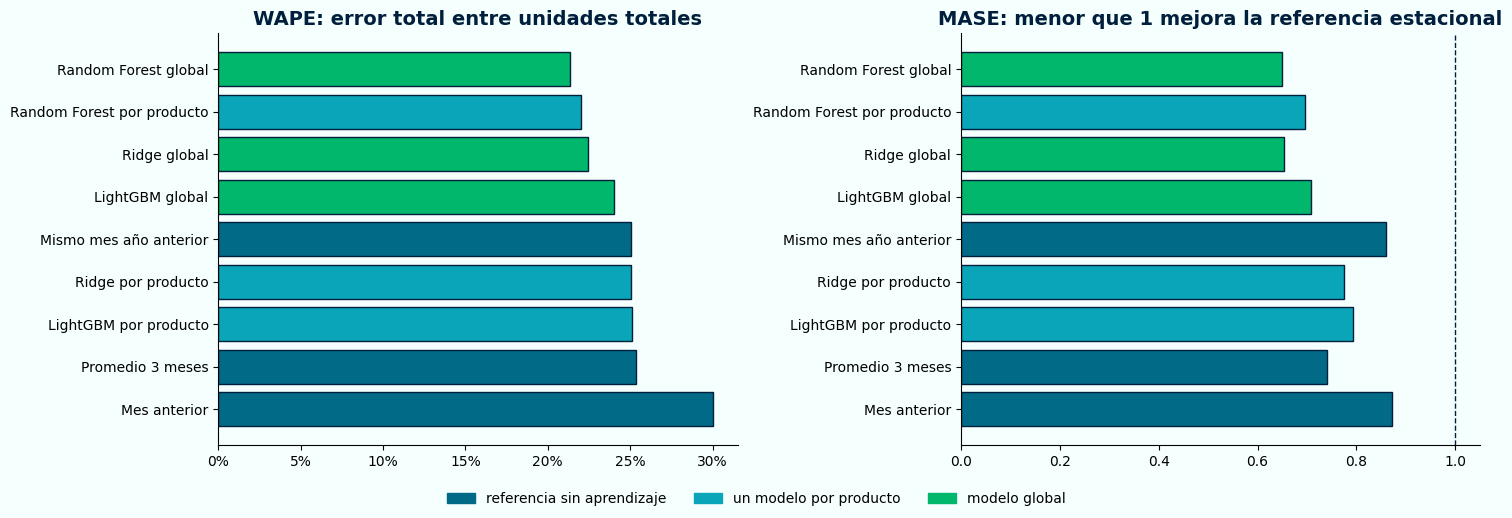

Mejor global: Random Forest global, WAPE 21.3%  |  mejor por producto: Random Forest por producto, WAPE 22.0%
Diferencia de WAPE, global menos por producto, IC 95%: -2.6% a +1.3%  |  P(global mejor) = 77%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
orden = MET_PRON.index.tolist()
col = lambda m: C_WRONG if m in BASELINES_PRON else (C_RIGHT if 'global' in m else C_TEAL)
axes[0].barh(orden, MET_PRON['WAPE'], color=[col(m) for m in orden], edgecolor=C_DARK)
axes[0].set_title('WAPE: error total entre unidades totales'); axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
axes[1].barh(orden, MET_PRON['MASE'], color=[col(m) for m in orden], edgecolor=C_DARK)
axes[1].axvline(1, color=C_DARK, linestyle='--', linewidth=1)
axes[1].set_title('MASE: menor que 1 mejora la referencia estacional'); axes[1].invert_yaxis()
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=C_WRONG, label='referencia sin aprendizaje'), Patch(color=C_TEAL, label='un modelo por producto'),
                    Patch(color=C_RIGHT, label='modelo global')], loc='lower center', ncol=3, frameon=False)
plt.tight_layout(rect=(0, 0.06, 1, 1)); plt.show()

mejor_global = MET_PRON.loc[[f'{a} global' for a in ALGORITMOS]].sort_values('WAPE').index[0]
mejor_local = MET_PRON.loc[[f'{a} por producto' for a in ALGORITMOS]].sort_values('WAPE').index[0]
GLOBAL_VS_LOCAL = bootstrap_wape(mejor_global, mejor_local)
print(f"Mejor global: {mejor_global}, WAPE {MET_PRON.loc[mejor_global, 'WAPE']:.1%}  |  "
      f"mejor por producto: {mejor_local}, WAPE {MET_PRON.loc[mejor_local, 'WAPE']:.1%}")
print(f"Diferencia de WAPE, global menos por producto, IC 95%: {GLOBAL_VS_LOCAL[0]:+.1%} a {GLOBAL_VS_LOCAL[1]:+.1%}  |  "
      f"P(global mejor) = {GLOBAL_VS_LOCAL[2]:.0%}")

In [ ]:
ELEGIDO_POR_METRICA = {}
for gr, tabla in MET_GRUPO.items():
    rank = pd.DataFrame({f'Posición por {c}': tabla[c].rank().astype(int) for c in ['MAPE', 'WAPE', 'MASE']}).sort_values('Posición por WAPE')
    ELEGIDO_POR_METRICA[gr] = {c: tabla[c].idxmin() for c in ['MAPE', 'WAPE', 'MASE']}
    print(f"{gr}: ¿las tres métricas eligen el mismo modelo?  →  " +
          ", ".join(f"{c} elige {m}" for c, m in ELEGIDO_POR_METRICA[gr].items()))
    display(rank)

mape_prod = (PRON.assign(ape=(PRON['yhat'] - PRON['y']).abs() / PRON['y'].where(PRON['y'] > 0))
             .groupby('producto')['ape'].mean())
vol = MENSUAL.loc[MENSUAL.index >= INICIO_BACKTEST].mean()
tabla_mape = pd.DataFrame({'Grupo': pd.Series(GRUPO), 'MAPE medio, todos los métodos': mape_prod.round(3),
                           'Unidades por mes': vol.reindex(mape_prod.index).round(0)}).sort_values('Unidades por mes')
print("El MAPE de cada producto contra su volumen: los productos chicos concentran los errores porcentuales grandes.")
display(tabla_mape)

Alto volumen: ¿las tres métricas eligen el mismo modelo?  →  MAPE elige Ridge global, WAPE elige Random Forest global, MASE elige Random Forest global


,Posición por MAPE,Posición por WAPE,Posición por MASE
Random Forest global,2,1,1
Random Forest por producto,3,2,3
Ridge global,1,3,2
LightGBM global,4,4,4
Mismo mes año anterior,6,5,7
LightGBM por producto,7,6,6
Ridge por producto,9,7,8
Promedio 3 meses,5,8,5
Mes anterior,8,9,9


Volumen medio: ¿las tres métricas eligen el mismo modelo?  →  MAPE elige Ridge global, WAPE elige Ridge global, MASE elige Ridge global


,Posición por MAPE,Posición por WAPE,Posición por MASE
Ridge global,1,1,1
Random Forest global,3,2,2
Random Forest por producto,2,3,3
LightGBM global,5,4,4
Promedio 3 meses,4,5,5
Ridge por producto,6,6,6
LightGBM por producto,7,7,7
Mes anterior,8,8,8
Mismo mes año anterior,9,9,9


El MAPE de cada producto contra su volumen: los productos chicos concentran los errores porcentuales grandes.


,Grupo,"MAPE medio, todos los métodos",Unidades por mes
SKU-00201,Volumen medio,1.255,16.0
SKU-00026,Volumen medio,0.832,20.0
SKU-00171,Volumen medio,0.742,20.0
SKU-00025,Volumen medio,0.602,22.0
SKU-00183,Volumen medio,0.816,22.0
SKU-00065,Volumen medio,0.855,22.0
SKU-00054,Volumen medio,1.161,23.0
SKU-00064,Volumen medio,0.848,25.0
SKU-00016,Volumen medio,0.486,28.0
SKU-00048,Volumen medio,0.540,29.0


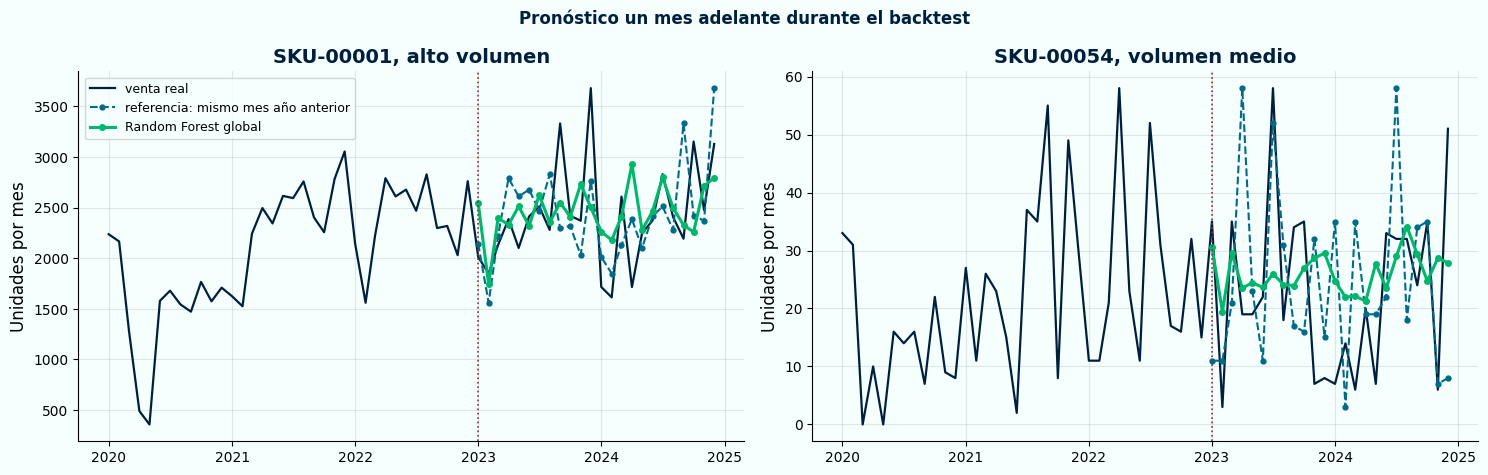

In [ ]:
mejor_ml = MET_PRON.drop(list(BASELINES_PRON)).index[0]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, prod_ej in zip(axes, [TOP[0], MEDIOS[0]]):
    g = PRON[PRON['producto'] == prod_ej].pivot(index='origen', columns='metodo', values='yhat')
    ax.plot(MENSUAL.index, MENSUAL[prod_ej], color=C_DARK, linewidth=1.6, label='venta real')
    ax.plot(g.index, g[REFERENCIA], color=C_WRONG, linestyle='--', marker='o', markersize=3.5, label=f'referencia: {REFERENCIA.lower()}')
    ax.plot(g.index, g[mejor_ml], color=C_RIGHT, linewidth=2.2, marker='o', markersize=4, label=mejor_ml)
    ax.axvline(pd.Timestamp(INICIO_BACKTEST), color=C_ERROR, linestyle=':', linewidth=1.2)
    ax.set_title(f'{prod_ej}, {GRUPO[prod_ej].lower()}'); ax.set_ylabel('Unidades por mes'); ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=9)
plt.suptitle('Pronóstico un mes adelante durante el backtest', color=C_DARK, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Detección de anomalías

La pregunta de negocio es: **¿qué días la venta de un producto no encaja con lo esperado?** El dataset sintético contiene casos conocidos de cuatro tipos:

- **Pedido atípico evidente:** un cliente compra de 6 a 12 veces el volumen normal de un día.
- **Pedido atípico moderado:** de 2.5 a 4 veces lo normal. Es el caso difícil, porque la venta diaria ya es irregular por sí sola.
- **Error de captura:** una cantidad registrada cien veces más grande. Contamina inventario, pronóstico y reportes.
- **Quiebre de stock:** de 4 a 7 días seguidos sin vender un producto que normalmente se vende casi todos los días. Es venta perdida.

Y hay dos cosas que **no** son anomalías aunque se vean raras: el pico de diciembre y la caída por la pandemia. Por eso la evaluación se reporta dos veces: con el periodo completo y solo con la operación posterior a la pandemia, que es el escenario real de monitoreo.

### Decisión: ¿qué método de detección usar?

**¿IQR global, DBSCAN, Isolation Forest, z robusto o z robusto con rachas de cero?**

- **IQR global** y **DBSCAN**, los métodos de la versión anterior, comparan cada día contra la distribución de toda la serie. Son simples, pero no saben qué es normal para cada momento.
- **Isolation Forest** aísla los días fáciles de separar del resto. Recibe la venta del día, su desviación respecto de lo esperado para ese día y el día de la semana, con un presupuesto de revisión del 1% de los días.
- **z robusto sobre el residuo** compara cada día contra lo esperado: la mediana de los mismos días de la semana en las 4 semanas anteriores. La dispersión se mide con la desviación absoluta mediana de los 60 días previos, que no se deja arrastrar por las propias anomalías.
- **Rachas de cero** mide qué tan improbable es una racha de días sin venta, dada la frecuencia con la que ese producto no se vendía antes de que empezara la racha. La alerta se dispara el día en que la racha se vuelve improbable y marca la racha completa desde su inicio.
- **z robusto con rachas de cero** combina los dos anteriores: uno vigila los días con demasiada venta y el otro los periodos sin venta.

Los tres últimos solo usan el pasado, así que funcionan igual en monitoreo diario. Todos se evalúan contra las anomalías inyectadas, que ninguno de ellos ve.

Explora esta decisión en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/prediccion-ventas-segmentacion-anomalias/#explorador-deteccion_anomalias)


In [ ]:
def esperado_semanal(x):
    """Mediana de los mismos días de la semana en las 4 semanas anteriores."""
    por_dia = x.groupby(x.index.dayofweek)
    return pd.concat([por_dia.shift(k) for k in range(1, 5)], axis=1).median(axis=1)

def z_robusto(x):
    """Solo usa el pasado: el valor de t depende de días anteriores a t."""
    resid = x - esperado_semanal(x)
    mad = resid.shift(1).rolling(60, min_periods=30).apply(lambda r: np.nanmedian(np.abs(r - np.nanmedian(r))), raw=True)
    return resid / (1.4826 * mad).clip(lower=1.0)

def rachas_cero(x, ventana=120):
    """Probabilidad de la racha actual de días sin venta, con la tasa de ceros previa al inicio de la racha."""
    cero = (x == 0).astype(int)
    grupo = (cero != cero.shift()).cumsum()
    largo = cero.groupby(grupo).cumsum()
    p0 = cero.shift(1).rolling(ventana, min_periods=30).mean().clip(0.01, 0.99)
    p0_inicio = p0.where(largo == 1).ffill()
    log_prob = largo * np.log(p0_inicio)
    alerta_dia = ((log_prob < np.log(ALPHA_RACHA)) & (largo > 0)).fillna(False)
    racha_alertada = alerta_dia.groupby(grupo).transform('max').astype(bool) & (cero == 1)
    puntaje = (-log_prob).where(largo > 0, 0).fillna(0).groupby(grupo).transform('max').where(cero == 1, 0)
    return racha_alertada, puntaje, alerta_dia

def detector_iqr(x):
    q1, q3 = x.quantile(0.25), x.quantile(0.75); iqr = max(q3 - q1, 1e-9)
    score = np.maximum.reduce([(q1 - x) / iqr, (x - q3) / iqr, np.zeros(len(x))])
    return pd.Series(score > 1.5, index=x.index), pd.Series(score, index=x.index)

def detector_dbscan(x):
    z = StandardScaler().fit_transform(x.values.reshape(-1, 1))
    dist = NearestNeighbors(n_neighbors=5).fit(z).kneighbors(z)[0][:, 4]
    eps = max(float(np.percentile(dist, 90)), 0.1)
    etiquetas = DBSCAN(eps=eps, min_samples=5).fit_predict(z)
    return pd.Series(etiquetas == -1, index=x.index), None

def detector_iforest(x):
    esp = esperado_semanal(x)
    X = pd.DataFrame({'log_venta': np.log1p(x), 'log_desviacion': np.log1p(x) - np.log1p(esp),
                      'dia_semana': x.index.dayofweek}).dropna()
    iso = IsolationForest(n_estimators=300, contamination=PRESUPUESTO_ALERTAS, random_state=SEED).fit(X)
    flag = pd.Series(iso.predict(X) == -1, index=X.index).reindex(x.index, fill_value=False)
    score = pd.Series(-iso.score_samples(X), index=X.index).reindex(x.index).fillna(0)
    return flag, score

def detector_z(x):
    z = z_robusto(x)
    return (z.abs() > UMBRAL_Z).fillna(False), z.abs().fillna(0)

def detector_rachas(x):
    flag, puntaje, _ = rachas_cero(x)
    return flag, puntaje

def detector_z_rachas(x):
    fz, sz = detector_z(x)
    fr, sr = detector_rachas(x)
    return fz | fr, np.maximum(sz / UMBRAL_Z, sr / -np.log(ALPHA_RACHA))

DETECTORES = {'IQR global': detector_iqr, 'DBSCAN': detector_dbscan, 'Isolation Forest': detector_iforest,
              'z robusto': detector_z, 'Rachas de cero': detector_rachas, 'z robusto con rachas de cero': detector_z_rachas}

# Los detectores reciben solo la venta diaria; las etiquetas se construyen aparte para evaluar.
ALERTAS, PUNTAJES = {}, {}
for nombre, fn in DETECTORES.items():
    fl, sc = {}, {}
    for p in TOP:
        f, s = fn(diario_top[p])
        fl[p] = f.astype(bool); sc[p] = s if s is not None else pd.Series(np.nan, index=diario_top.index)
    ALERTAS[nombre] = pd.DataFrame(fl); PUNTAJES[nombre] = pd.DataFrame(sc)

VERDAD = pd.DataFrame(0, index=diario_top.index, columns=TOP)
TIPO = pd.DataFrame('', index=diario_top.index, columns=TOP)
for _, r in ETIQUETAS_ANOMALIAS.iterrows():
    if r['Codigo_Producto'] in TOP and r['Fecha_Emision'] in VERDAD.index:
        VERDAD.loc[r['Fecha_Emision'], r['Codigo_Producto']] = 1
        TIPO.loc[r['Fecha_Emision'], r['Codigo_Producto']] = r['Tipo']
print(f"Productos analizados con anomalías inyectadas: {int((VERDAD.sum() > 0).sum())} de {len(TOP)}  |  "
      f"días anómalos: {int(VERDAD.values.sum())} de {VERDAD.size:,} producto-día ({VERDAD.values.mean():.2%})")
print("Días anómalos por tipo:", pd.Series(TIPO.values.ravel()).replace('', np.nan).dropna().value_counts().to_dict())

Productos analizados con anomalías inyectadas: 10 de 10  |  días anómalos: 188 de 15,540 producto-día (1.21%)
Días anómalos por tipo: {'quiebre_stock': 108, 'pedido_atipico': 30, 'pedido_moderado': 30, 'error_captura': 20}


In [ ]:
TIPOS = ['pedido_atipico', 'pedido_moderado', 'error_captura', 'quiebre_stock']
pos_dia = np.arange(len(VERDAD))
dias_pandemia = (VERDAD.index >= '2020-03-16') & (VERDAD.index <= '2021-03-31')
dias_diciembre = VERDAD.index.month == 12
CORTES = {'Periodo completo': pos_dia >= DIAS_CALENTAMIENTO,
          'Posterior a la pandemia': np.asarray(VERDAD.index >= INICIO_POSPANDEMIA)}

def evaluar_detectores(mask):
    y_true = VERDAD.values[mask].ravel(); tipo = TIPO.values[mask].ravel()
    en_pand = np.repeat(dias_pandemia[mask], len(TOP)); en_dic = np.repeat(dias_diciembre[mask], len(TOP))
    filas = []
    for nombre in DETECTORES:
        y_pred = ALERTAS[nombre].values[mask].ravel().astype(int)
        sc = PUNTAJES[nombre].values[mask].ravel().astype(float)
        fp = (y_pred == 1) & (y_true == 0)
        fila = {'Método': nombre, 'Alertas': int(y_pred.sum()),
                'Precisión': precision_score(y_true, y_pred, zero_division=0),
                'Recall': recall_score(y_true, y_pred, zero_division=0),
                'F1': f1_score(y_true, y_pred, zero_division=0),
                'Precisión promedio, sin umbral': average_precision_score(y_true, sc) if not np.isnan(sc).all() else np.nan,
                'Falsas alarmas en pandemia': int((fp & en_pand).sum()),
                'Falsas alarmas en diciembre': int((fp & en_dic).sum())}
        for t in TIPOS:
            m = tipo == t
            fila[f'Recall {t.replace("_", " ")}'] = y_pred[m].mean() if m.any() else np.nan
        filas.append(fila)
    return pd.DataFrame(filas).set_index('Método').sort_values('F1', ascending=False)

MET_ANOM_CORTES = {c: evaluar_detectores(m) for c, m in CORTES.items()}
MET_ANOM = MET_ANOM_CORTES['Posterior a la pandemia']
for c, t in MET_ANOM_CORTES.items():
    print(c)
    display((t if c == 'Periodo completo' else t.drop(columns='Falsas alarmas en pandemia')).round(3))

Periodo completo


,Alertas,Precisión,Recall,F1,"Precisión promedio, sin umbral",Falsas alarmas en pandemia,Falsas alarmas en diciembre,Recall pedido atipico,Recall pedido moderado,Recall error captura,Recall quiebre stock
Método,,,,,,,,,,,
z robusto con rachas de cero,457,0.344,0.835,0.487,0.567,233,9,1.000,0.433,1.0,0.87
Rachas de cero,241,0.390,0.500,0.438,0.307,125,0,0.000,0.000,0.0,0.87
DBSCAN,98,0.633,0.330,0.434,NaN,3,8,1.000,0.400,1.0,0.00
Isolation Forest,157,0.363,0.303,0.330,0.291,29,10,0.767,0.067,0.9,0.13
z robusto,216,0.292,0.335,0.312,0.289,108,9,1.000,0.433,1.0,0.00
IQR global,337,0.214,0.383,0.274,0.371,24,46,1.000,0.733,1.0,0.00


Posterior a la pandemia


,Alertas,Precisión,Recall,F1,"Precisión promedio, sin umbral",Falsas alarmas en diciembre,Recall pedido atipico,Recall pedido moderado,Recall error captura,Recall quiebre stock
Método,,,,,,,,,,
z robusto con rachas de cero,192,0.651,0.817,0.725,0.824,4,1.00,0.44,1.000,0.833
Rachas de cero,92,0.761,0.458,0.571,0.459,0,0.00,0.00,0.000,0.833
DBSCAN,88,0.625,0.359,0.456,NaN,8,1.00,0.44,1.000,0.000
z robusto,100,0.550,0.359,0.435,0.391,4,1.00,0.44,1.000,0.000
Isolation Forest,121,0.421,0.333,0.372,0.408,5,0.76,0.04,0.895,0.167
IQR global,302,0.205,0.405,0.273,0.398,41,1.00,0.72,1.000,0.000


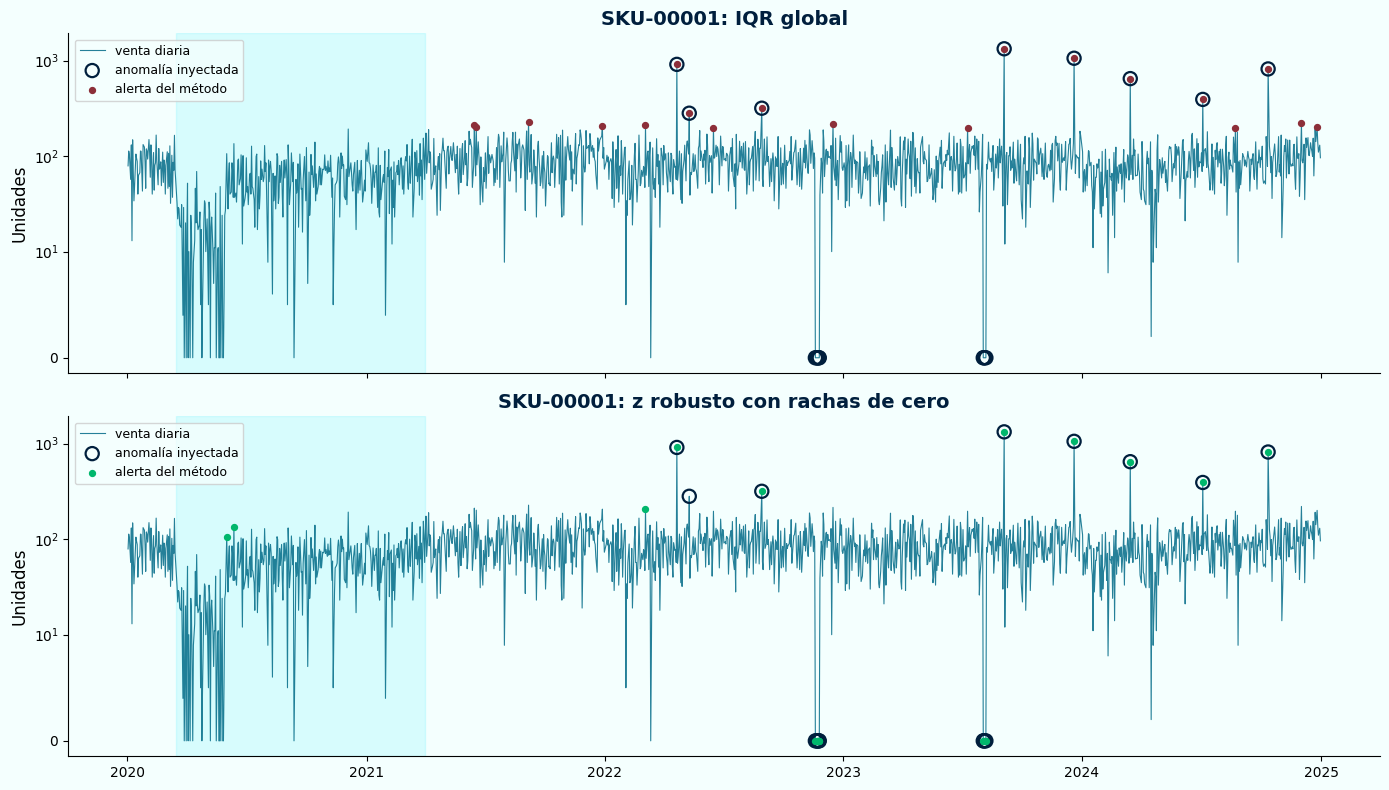

In [ ]:
prod_a = TOP[0]
x = diario_top[prod_a]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, metodo in zip(axes, ['IQR global', 'z robusto con rachas de cero']):
    ax.plot(x.index, x.values, color=C_WRONG, linewidth=0.8, alpha=0.85, label='venta diaria')
    real = (VERDAD[prod_a] == 1).values
    ax.scatter(x.index[real], x.values[real], s=90, facecolors='none', edgecolors=C_DARK, linewidths=1.6, label='anomalía inyectada', zorder=4)
    al = ALERTAS[metodo][prod_a].values.astype(bool)
    ax.scatter(x.index[al], x.values[al], s=18, color=C_ERROR if metodo == 'IQR global' else C_RIGHT, label='alerta del método', zorder=5)
    ax.axvspan(pd.Timestamp('2020-03-16'), pd.Timestamp('2021-03-31'), color=C_ACCENT, alpha=0.15)
    ax.set_title(f'{prod_a}: {metodo}'); ax.set_ylabel('Unidades'); ax.set_yscale('symlog', linthresh=10)
    ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

## 7. Segmentación de clientes

La pregunta de negocio es: **¿qué tipos de cliente tiene el negocio y a quién conviene cuidar?** Se describe a cada cliente con tres números, el esquema RFM:

- **Recencia:** días desde su última compra.
- **Frecuencia:** cuántos documentos de compra tiene.
- **Valor monetario:** cuánto compró en total, descontando devoluciones.

El RFM se calcula con datos **hasta el 31 de diciembre de 2023**. Todo 2024 queda fuera, y se usa para responder la pregunta que de verdad importa: ¿los segmentos anticipan quién vuelve a comprar y cuánto gasta?

### Decisión: ¿K-means, mezcla gaussiana o reglas RFM por quintiles?

**¿Qué método de segmentación usar?**

- **K-means** agrupa clientes cercanos entre sí. Es el más usado y el de la versión anterior.
- **Mezcla gaussiana, GMM,** permite grupos de distinta forma y tamaño, a cambio de más parámetros.
- **Reglas RFM por quintiles** es la práctica clásica de marketing: calificar cada cliente del 1 al 5 en cada dimensión y nombrar segmentos con reglas fijas. No aprende nada, y justo por eso es la vara con la que se mide a los otros dos.

Cada método se evalúa en tres niveles: qué tan separados quedan los grupos, qué tan estables son si cambian un poco los datos, y **cuánto dicen del comportamiento en 2024**. Como los datos son sintéticos, además se puede comparar contra el tipo real de cada cliente, algo imposible con datos reales.

Explora esta decisión en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/prediccion-ventas-segmentacion-anomalias/#explorador-segmentacion_metodo)


In [ ]:
hist = MOVIMIENTOS[MOVIMIENTOS['Fecha_Emision'] < FIN_AJUSTE_SEGMENTOS]
fut = MOVIMIENTOS[MOVIMIENTOS['Fecha_Emision'] >= FIN_AJUSTE_SEGMENTOS]
RFM = hist.groupby('Cliente').agg(ultima=('Fecha_Emision', 'max'),
                                  frecuencia=('Documento', lambda d: d[~d.str.endswith('-D')].nunique()),
                                  monetario=('Valor_Venta', 'sum'))
RFM['recencia'] = (pd.Timestamp(FIN_AJUSTE_SEGMENTOS) - RFM['ultima']).dt.days
RFM = RFM[(RFM['monetario'] > 0) & (RFM['frecuencia'] > 0)].drop(columns='ultima')

X_RFM = np.log1p(RFM[['recencia', 'frecuencia', 'monetario']])
ESCALADOR_RFM = StandardScaler().fit(X_RFM)
XS = ESCALADOR_RFM.transform(X_RFM)

compra_2024 = RFM.index.isin(fut.loc[fut['Cantidad'] > 0, 'Cliente'].unique()).astype(int)
gasto_2024 = fut.groupby('Cliente')['Valor_Venta'].sum().reindex(RFM.index).fillna(0).values
real = SEGMENTO_REAL.set_index('Cliente')['Segmento_real'].reindex(RFM.index).values
print(f"{len(RFM):,} clientes con compras hasta 2023  |  {compra_2024.mean():.1%} volvió a comprar en 2024")
RFM.describe().round(1)

12,515 clientes con compras hasta 2023  |  9.7% volvió a comprar en 2024


,frecuencia,monetario,recencia
count,12515.0,12515.0,12515.0
mean,3.8,2876.8,634.5
std,13.3,16335.4,428.4
min,1.0,12.8,2.0
25%,1.0,136.7,240.0
50%,1.0,307.7,612.0
75%,2.0,641.0,991.0
max,290.0,363704.2,1460.0


In [ ]:
H_RECOMPRA = entropy(np.bincount(compra_2024) / len(compra_2024))
rng_est = np.random.default_rng(SEED)

def evaluar(labels, estable=None):
    tasas = pd.Series(compra_2024).groupby(labels).mean()
    return {'Segmentos': int(len(np.unique(labels))),
            'Segmento más chico': float(pd.Series(labels).value_counts(normalize=True).min()),
            'Silhouette': silhouette_score(XS, labels, sample_size=min(MUESTRA_SILHOUETTE, len(XS)), random_state=SEED),
            'Davies-Bouldin': davies_bouldin_score(XS, labels),
            'Estabilidad, ARI': estable,
            'Recompra 2024 explicada': mutual_info_score(labels, compra_2024) / H_RECOMPRA,
            'Brecha de recompra 2024': float(tasas.max() - tasas.min()),
            'ARI contra tipo real': adjusted_rand_score(real, labels)}

def estabilidad(ajustar, k, base):
    aris = []
    n = len(XS)
    for _ in range(N_ESTABILIDAD):
        idx = rng_est.choice(n, int(0.8 * n), replace=False)
        aris.append(adjusted_rand_score(base, ajustar(k, XS[idx]).predict(XS)))
    return float(np.mean(aris))

ajustar_km = lambda k, X: KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
ajustar_gm = lambda k, X: GaussianMixture(n_components=k, covariance_type='full', n_init=3, random_state=SEED).fit(X)

filas, ETIQ = [], {}
for k in K_RANGO:
    km = ajustar_km(k, XS); lab = km.predict(XS); ETIQ[('K-means', k)] = lab
    filas.append({'Método': 'K-means', 'k': k, **evaluar(lab, estabilidad(ajustar_km, k, lab))})
    gm = ajustar_gm(k, XS); lab = gm.predict(XS); ETIQ[('GMM', k)] = lab
    filas.append({'Método': 'GMM', 'k': k, 'BIC': gm.bic(XS), **evaluar(lab, estabilidad(ajustar_gm, k, lab))})
MET_K = pd.DataFrame(filas)
MET_K.round(3)

,Método,k,Segmentos,Segmento más chico,Silhouette,Davies-Bouldin,"Estabilidad, ARI",Recompra 2024 explicada,Brecha de recompra 2024,ARI contra tipo real,BIC
0,K-means,2,2,0.105,0.609,0.802,0.994,0.277,0.519,0.378,NaN
1,GMM,2,2,0.232,0.493,1.117,0.985,0.321,0.349,0.359,72185.381
2,K-means,3,3,0.071,0.417,0.987,0.953,0.358,0.563,0.265,NaN
3,GMM,3,3,0.165,0.173,1.392,0.997,0.280,0.404,0.259,-7185.445
4,K-means,4,4,0.055,0.351,0.918,0.923,0.330,0.642,0.199,NaN
5,GMM,4,4,0.082,0.129,1.806,0.995,0.265,0.477,0.267,-37287.048
6,K-means,5,5,0.029,0.340,0.915,0.981,0.375,0.748,0.154,NaN
7,GMM,5,5,0.034,0.141,2.012,1.000,0.241,0.594,0.281,-46672.300
8,K-means,6,6,0.029,0.340,0.910,0.953,0.389,0.760,0.132,NaN
9,GMM,6,6,0.035,0.150,1.928,0.993,0.280,0.602,0.277,-47074.713


In [ ]:
# Reglas RFM por quintiles: la práctica clásica, sin aprendizaje.
# Recencia y valor monetario se califican por quintiles; los empates reciben la misma calificación.
# La frecuencia tiene demasiados empates, la mayoría de los clientes compró una sola vez,
# así que se califica con cortes fijos: 1 compra, 2, de 3 a 4, de 5 a 9, 10 o más.
def quintil(s, invertir=False):
    q = np.ceil(s.rank(method='average', pct=True) * 5).clip(1, 5).astype(int)
    return 6 - q if invertir else q

R = quintil(RFM['recencia'], invertir=True)
F = pd.cut(RFM['frecuencia'], bins=[0, 1, 2, 4, 9, np.inf], labels=[1, 2, 3, 4, 5]).astype(int)
M = quintil(RFM['monetario'])
QUINTILES = np.select([(R >= 4) & (F >= 4), (F >= 4) & (R <= 2), F >= 4, R >= 4, R <= 2],
                      ['Campeones', 'Leales en riesgo', 'Leales', 'Recientes', 'Inactivos'], default='Intermedios')
ETIQ[('Quintiles RFM', len(np.unique(QUINTILES)))] = QUINTILES

# Regla para elegir k, fijada antes de ver 2024: el mejor silhouette entre las opciones estables
# (ARI de estabilidad de al menos 0.8) sin segmentos menores al 3% de los clientes.
def elegir_k(df):
    ok = df[(df['Estabilidad, ARI'] >= 0.8) & (df['Segmento más chico'] >= 0.03)]
    return int((ok if len(ok) else df).sort_values('Silhouette', ascending=False)['k'].iloc[0])

K_KM = elegir_k(MET_K[MET_K['Método'] == 'K-means'])
K_GM = elegir_k(MET_K[MET_K['Método'] == 'GMM'])
MET_SEG = pd.DataFrame([
    {'Método': f'K-means, k={K_KM}', **MET_K[(MET_K['Método'] == 'K-means') & (MET_K['k'] == K_KM)].iloc[0].drop(['Método', 'k', 'BIC']).to_dict()},
    {'Método': f'GMM, k={K_GM}', **MET_K[(MET_K['Método'] == 'GMM') & (MET_K['k'] == K_GM)].iloc[0].drop(['Método', 'k', 'BIC']).to_dict()},
    {'Método': 'Quintiles RFM', **evaluar(QUINTILES)},
]).set_index('Método')
print(f"k elegido por la regla: K-means {K_KM}, GMM {K_GM}")
MET_SEG.round(3)

k elegido por la regla: K-means 2, GMM 2


,Segmentos,Segmento más chico,Silhouette,Davies-Bouldin,"Estabilidad, ARI",Recompra 2024 explicada,Brecha de recompra 2024,ARI contra tipo real
Método,,,,,,,,
"K-means, k=2",2,0.105,0.609,0.802,0.994,0.277,0.519,0.378
"GMM, k=2",2,0.232,0.493,1.117,0.985,0.321,0.349,0.359
Quintiles RFM,6,0.010,0.080,3.203,NaN,0.369,0.648,0.116


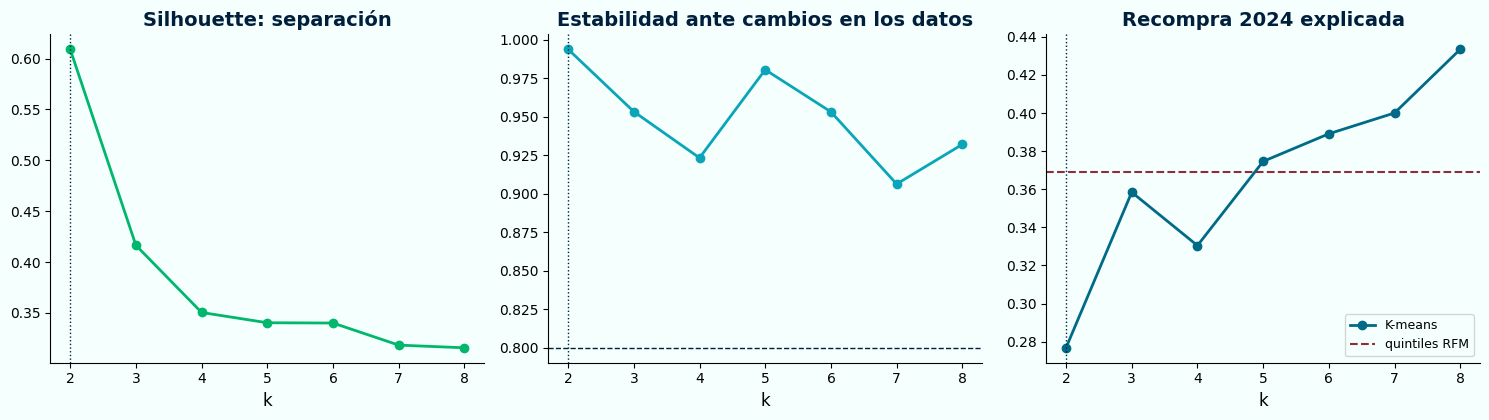

In [ ]:
km_tabla = MET_K[MET_K['Método'] == 'K-means'].set_index('k')
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
axes[0].plot(km_tabla.index, km_tabla['Silhouette'], color=C_RIGHT, marker='o', linewidth=2)
axes[0].set_title('Silhouette: separación'); axes[0].set_xlabel('k')
axes[1].plot(km_tabla.index, km_tabla['Estabilidad, ARI'], color=C_TEAL, marker='o', linewidth=2)
axes[1].axhline(0.8, color=C_DARK, linestyle='--', linewidth=1); axes[1].set_title('Estabilidad ante cambios en los datos'); axes[1].set_xlabel('k')
axes[2].plot(km_tabla.index, km_tabla['Recompra 2024 explicada'], color=C_WRONG, marker='o', linewidth=2, label='K-means')
axes[2].axhline(MET_SEG.loc['Quintiles RFM', 'Recompra 2024 explicada'], color=C_ERROR, linestyle='--', label='quintiles RFM')
axes[2].set_title('Recompra 2024 explicada'); axes[2].set_xlabel('k'); axes[2].legend(fontsize=9)
for ax in axes:
    ax.axvline(K_KM, color=C_DARK, linestyle=':', linewidth=1)
plt.tight_layout(); plt.show()

Perfil de los segmentos K-means, k=2, ordenados por valor monetario. La recompra y el gasto son de 2024, que el modelo no vio.


,clientes,recencia_mediana,frecuencia_mediana,monetario_mediano,recompra_2024,gasto_2024_medio
Segmento 1,1310,73.0,10.0,3631.32,0.56,6271.01
Segmento 2,11205,682.0,1.0,263.60,0.04,43.59


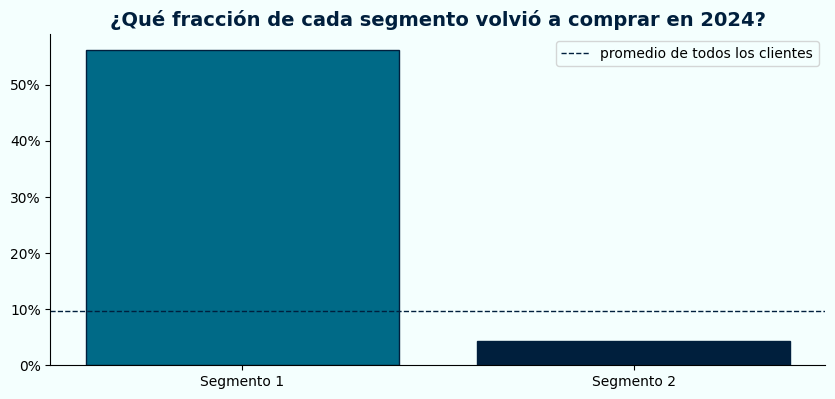

In [ ]:
lab = ETIQ[('K-means', K_KM)]
perfil = RFM.assign(segmento=lab, compra_2024=compra_2024, gasto_2024=gasto_2024).groupby('segmento').agg(
    clientes=('recencia', 'size'), recencia_mediana=('recencia', 'median'), frecuencia_mediana=('frecuencia', 'median'),
    monetario_mediano=('monetario', 'median'), recompra_2024=('compra_2024', 'mean'), gasto_2024_medio=('gasto_2024', 'mean'))
perfil = perfil.sort_values('monetario_mediano', ascending=False)
perfil.index = [f'Segmento {i + 1}' for i in range(len(perfil))]
print(f"Perfil de los segmentos K-means, k={K_KM}, ordenados por valor monetario. La recompra y el gasto son de 2024, que el modelo no vio.")
display(perfil.round(2))

fig, ax = plt.subplots(figsize=(10, 4.3))
ax.bar(perfil.index, perfil['recompra_2024'], color=brand_colors(len(perfil)), edgecolor=C_DARK)
ax.axhline(compra_2024.mean(), color=C_DARK, linestyle='--', linewidth=1, label='promedio de todos los clientes')
ax.set_title('¿Qué fracción de cada segmento volvió a comprar en 2024?')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}')); ax.legend()
plt.show()

## 8. Exportación para el Explorador de decisiones

- Los resultados de cada alternativa se guardan en `explorador_resultados.json`, organizados por decisión.
- Cuando el artículo tenga sus anclas, el Explorador puede leer de aquí los números reales de cada opción.
- También se guardan las tablas completas en CSV.

In [ ]:
def limpiar(d):
    out = {}
    for k, v in d.items():
        if isinstance(v, (float, np.floating)):
            out[k] = None if not np.isfinite(v) else round(float(v), 4)
        elif isinstance(v, (int, np.integer)):
            out[k] = int(v)
        else:
            out[k] = v
    return out

mejor_ref = MET_PRON.loc[list(BASELINES_PRON)].sort_values('WAPE').index[0]
EXPLORADOR = {
    'meta': {'ejecutado': datetime.now().strftime('%Y-%m-%d'), 'dataset': 'sintético',
             'backtest_pronostico': [str(ORIGENES[0].date()), str(ORIGENES[-1].date())],
             'productos_pronostico': {'alto_volumen': TOP, 'volumen_medio': MEDIOS},
             'anclas_pendientes': ['nivel_agregacion', 'modelo_global', 'metrica_pronostico', 'deteccion_anomalias', 'segmentacion_metodo']},
    'nivel_agregacion': {'Diario': limpiar(AGREGACION['Diario'].to_dict()), 'Mensual': limpiar(AGREGACION['Mensual'].to_dict())},
    'modelo_global': {'Un modelo por producto': {'metodo': mejor_local, **limpiar(MET_PRON.loc[mejor_local].to_dict())},
                      'Un modelo global': {'metodo': mejor_global, **limpiar(MET_PRON.loc[mejor_global].to_dict())},
                      'Mejor referencia sin aprendizaje': {'metodo': mejor_ref, **limpiar(MET_PRON.loc[mejor_ref].to_dict())},
                      'Diferencia de WAPE global menos por producto': limpiar({'ic95_bajo': GLOBAL_VS_LOCAL[0], 'ic95_alto': GLOBAL_VS_LOCAL[1],
                                                                               'p_global_mejor': GLOBAL_VS_LOCAL[2]})},
    'metrica_pronostico': {gr: {'modelo_elegido_por': eleg} for gr, eleg in ELEGIDO_POR_METRICA.items()},
    'deteccion_anomalias': {corte: {m: limpiar(t.loc[m].to_dict()) for m in t.index} for corte, t in MET_ANOM_CORTES.items()},
    'segmentacion_metodo': {m: limpiar(MET_SEG.loc[m].to_dict()) for m in MET_SEG.index},
}
with open('explorador_resultados.json', 'w', encoding='utf-8') as fh:
    json.dump(EXPLORADOR, fh, ensure_ascii=False, indent=2, allow_nan=False)
MET_PRON.to_csv('metricas_pronostico.csv')
for gr, t in MET_GRUPO.items():
    t.to_csv(f"metricas_pronostico_{gr.lower().replace(' ', '_')}.csv")
for corte, t in MET_ANOM_CORTES.items():
    t.to_csv(f"metricas_anomalias_{corte.lower().replace(' ', '_')}.csv")
MET_K.to_csv('metricas_segmentacion_por_k.csv', index=False); MET_SEG.to_csv('metricas_segmentacion.csv')
print(json.dumps({k: v for k, v in EXPLORADOR.items() if k != 'meta'}, ensure_ascii=False, indent=1)[:1500], '...')

{
 "nivel_agregacion": {
  "Diario": {
   "Días o meses sin venta, alto volumen": 0.2091,
   "Días o meses sin venta, volumen medio": 0.8392,
   "Coef. de variación, alto volumen": 1.9116,
   "Coef. de variación, volumen medio": 2.9742
  },
  "Mensual": {
   "Días o meses sin venta, alto volumen": 0.0,
   "Días o meses sin venta, volumen medio": 0.0517,
   "Coef. de variación, alto volumen": 0.4434,
   "Coef. de variación, volumen medio": 0.6344
  }
 },
 "modelo_global": {
  "Un modelo por producto": {
   "metodo": "Random Forest por producto",
   "WAPE": 0.2204,
   "MASE": 0.6953,
   "MAPE": 0.5056,
   "Sesgo": 0.0241,
   "Unidades faltantes": 15167.332,
   "Unidades sobrantes": 18886.0066,
   "Productos donde mejora a la referencia": 18.0,
   "P(WAPE menor que la referencia)": 0.9765
  },
  "Un modelo global": {
   "metodo": "Random Forest global",
   "WAPE": 0.2133,
   "MASE": 0.6501,
   "MAPE": 0.5006,
   "Sesgo": 0.0446,
   "Unidades faltantes": 13033.3446,
   "Unidades sobrantes"

## Checklist metodológico

Cada punto se verifica con código en la celda siguiente. Si alguno falla, la celda se detiene con un error en vez de dejar pasar un resultado contaminado.

- **Datos sin identificadores reales.** Todo cliente, producto y documento sigue el formato ficticio del generador.
- **Limpieza completa.** No quedan duplicados, anulados, códigos que no son producto ni cantidades negativas en la demanda.
- **Productos elegidos sin mirar el backtest.** Los 20 productos del pronóstico se eligieron solo con ventas anteriores al primer mes pronosticado.
- **Sin fuga temporal en el pronóstico.** En cada mes pronosticado, todo el entrenamiento es anterior a ese mes, y la escala del modelo global se calculó solo con el entrenamiento.
- **Las variables son lo que dicen ser.** Los rezagos recalculados desde la serie original coinciden con los del panel.
- **Escala del MASE sin el backtest.** Solo usa meses anteriores al primer mes pronosticado.
- **Los detectores de monitoreo no miran el futuro.** El z robusto de un día y el disparo de la alerta de racha son idénticos si se calculan con la serie cortada en ese día.
- **Las etiquetas no llegan a los detectores.** Cada detector recibe solo la serie de ventas.
- **Las reglas RFM no desempatan al azar.** Clientes con la misma frecuencia reciben la misma calificación.
- **Segmentación sin 2024.** El RFM y su escalado usan solo datos hasta 2023. 2024 solo se usa para evaluar.

In [ ]:
rng_chk = np.random.default_rng(SEED)

assert crudo['Cliente'].str.fullmatch(r'CLI-\d{5}').all(), "Hay clientes con identificador no ficticio"
assert crudo['Codigo_Producto'].str.fullmatch(r'SKU-\d{5}|DCTO|TERCERO').all(), "Hay códigos de producto no ficticios"
assert crudo['Documento'].str.fullmatch(r'S\d-(\d{6}|A\d{5})(-D)?').all(), "Hay documentos con formato no ficticio"

assert not VENTAS.duplicated().any() and (VENTAS['Anulado'] == 'N').all()
assert VENTAS['Codigo_Producto'].str.startswith('SKU-').all() and (VENTAS['Cantidad'] > 0).all()

ranking_recalc = (VENTAS[VENTAS['Fecha_Emision'] < INICIO_BACKTEST].groupby('Codigo_Producto')['Cantidad'].sum()
                  .sort_values(ascending=False).index)
assert ranking_recalc[:N_PRODUCTOS].tolist() == TOP, "Los productos de alto volumen no se eligieron antes del backtest"
assert ranking_recalc[RANGO_MEDIOS[0]:RANGO_MEDIOS[1]].tolist() == MEDIOS, "Los productos de volumen medio no se eligieron antes del backtest"

lp = pd.DataFrame(LOG_PRONOSTICO)
assert (lp['max_mes_train'] < lp['origen']).all(), "Algún entrenamiento incluye el mes pronosticado o posteriores"
assert lp['escala_ok'].all(), "La escala del modelo global no corresponde al entrenamiento"

for _ in range(20):
    fila = PANEL.iloc[int(rng_chk.integers(len(PANEL)))]
    s = MENSUAL[fila['producto']]; pos = s.index.get_loc(fila['mes'])
    assert fila['lag_1'] == s.iloc[pos - 1] and fila['lag_12'] == s.iloc[pos - 12], "Un rezago no coincide con la serie"
    assert np.isclose(fila['media_3'], s.iloc[pos - 3:pos].mean()), "Un promedio móvil incluye el mes pronosticado"
assert PANEL[FEATURES].notna().all().all(), "Hay rezagos vacíos en el panel"

assert hist_mase.index.max() < pd.Timestamp(INICIO_BACKTEST), "La escala del MASE usa meses del backtest"

for _ in range(10):
    p = TOP[int(rng_chk.integers(len(TOP)))]
    t = int(rng_chk.integers(DIAS_CALENTAMIENTO, len(diario_top)))
    serie, corta = diario_top[p], diario_top[p].iloc[:t + 1]
    completo, recortado = z_robusto(serie).iloc[t], z_robusto(corta).iloc[-1]
    assert (np.isnan(completo) and np.isnan(recortado)) or np.isclose(completo, recortado), "El z robusto usa días futuros"
    assert rachas_cero(serie)[2].iloc[t] == rachas_cero(corta)[2].iloc[-1], "La alerta de racha usa días futuros"

assert set(diario_top.columns) == set(TOP) and 'Tipo' not in diario_top.columns

assert (pd.Series(F.values).groupby(RFM['frecuencia'].values).nunique() == 1).all(), "Clientes con la misma frecuencia tienen calificaciones distintas"
assert RFM.index.isin(hist['Cliente']).all() and hist['Fecha_Emision'].max() < pd.Timestamp(FIN_AJUSTE_SEGMENTOS)
assert np.allclose(ESCALADOR_RFM.mean_, X_RFM.mean().values), "El escalado del RFM no corresponde a los datos hasta 2023"

print("Checklist metodológico verificado:")
print(f"- {crudo['Cliente'].nunique():,} clientes, {crudo['Codigo_Producto'].nunique():,} códigos y {crudo['Documento'].nunique():,} documentos con identificadores ficticios")
print(f"- Demanda limpia: {len(VENTAS):,} líneas sin duplicados, anulados, no productos ni devoluciones")
print(f"- {len(PRODUCTOS_PRON)} productos de pronóstico elegidos antes del backtest, {len(lp)} entrenamientos auditados")
print("- 20 filas del panel recalculadas desde la serie original: rezagos y promedios correctos")
print("- 10 recálculos del z robusto y de la alerta de racha con la serie recortada coinciden: el monitoreo no mira el futuro")
print("- Calificación de frecuencia RFM idéntica para clientes con la misma frecuencia")
print(f"- RFM de {len(RFM):,} clientes con datos hasta {hist['Fecha_Emision'].max().date()}, 2024 solo para evaluar")

Checklist metodológico verificado:
- 15,961 clientes, 2,999 códigos y 63,044 documentos con identificadores ficticios
- Demanda limpia: 120,397 líneas sin duplicados, anulados, no productos ni devoluciones
- 20 productos de pronóstico elegidos antes del backtest, 504 entrenamientos auditados
- 20 filas del panel recalculadas desde la serie original: rezagos y promedios correctos
- 10 recálculos del z robusto y de la alerta de racha con la serie recortada coinciden: el monitoreo no mira el futuro
- Calificación de frecuencia RFM idéntica para clientes con la misma frecuencia
- RFM de 12,515 clientes con datos hasta 2023-12-30, 2024 solo para evaluar


## Resumen automático de resultados

Esta celda redacta los hallazgos con los números de esta corrida, para que la conclusión nunca se escriba antes de ver el resultado. Cuando una diferencia no es estadísticamente clara, el resumen lo dice.

In [ ]:
bl = MET_PRON.loc[list(BASELINES_PRON)].sort_values('WAPE')
ml = MET_PRON.drop(list(BASELINES_PRON)).sort_values('WAPE')
top_ml = ml.index[0]
p_top = ml['P(WAPE menor que la referencia)'].iloc[0]
veredicto = lambda p: 'mejora demostrada' if p >= 0.95 else ('mejora probable, no demostrada' if p >= 0.80 else 'no se distingue')

print("PRONÓSTICO")
print(f"• Nivel de agregación: {AGREGACION.loc['Días o meses sin venta, volumen medio', 'Diario']:.0%} de días sin venta en productos de volumen medio, "
      f"contra {AGREGACION.loc['Días o meses sin venta, volumen medio', 'Mensual']:.0%} de meses.")
print(f"• Referencia, la mejor alternativa sin aprendizaje: {REFERENCIA}, WAPE {MET_PRON.loc[REFERENCIA, 'WAPE']:.1%}, "
      f"MASE {MET_PRON.loc[REFERENCIA, 'MASE']:.2f}.")
print(f"• Mejor modelo: {top_ml}, WAPE {ml['WAPE'].iloc[0]:.1%}, MASE {ml['MASE'].iloc[0]:.2f}, mejora a la referencia en "
      f"{int(ml['Productos donde mejora a la referencia'].iloc[0])} de {len(PRODUCTOS_PRON)} productos; "
      f"P(WAPE menor que la referencia) = {p_top:.0%}, {veredicto(p_top)}.")
print(f"• Global contra por producto: {mejor_global} {MET_PRON.loc[mejor_global, 'WAPE']:.1%} vs {mejor_local} {MET_PRON.loc[mejor_local, 'WAPE']:.1%}; "
      f"P(global mejor) = {GLOBAL_VS_LOCAL[2]:.0%}, {veredicto(max(GLOBAL_VS_LOCAL[2], 1 - GLOBAL_VS_LOCAL[2]))}.")
for gr, eleg in ELEGIDO_POR_METRICA.items():
    coinciden = len(set(eleg.values())) == 1
    print(f"• Métricas en {gr.lower()}: " + ", ".join(f"{c} elige {m}" for c, m in eleg.items()) +
          (". Coinciden." if coinciden else ". No coinciden: la métrica cambia al ganador."))
print(f"• Faltantes y sobrantes con {top_ml}: {ml['Unidades faltantes'].iloc[0]:,.0f} y {ml['Unidades sobrantes'].iloc[0]:,.0f} unidades en 24 meses, "
      f"contra {MET_PRON.loc[REFERENCIA, 'Unidades faltantes']:,.0f} y {MET_PRON.loc[REFERENCIA, 'Unidades sobrantes']:,.0f} con la referencia.")

print("\nANOMALÍAS, operación posterior a la pandemia")
a = MET_ANOM
print(f"• Mejor detector por F1: {a.index[0]}, precisión {a['Precisión'].iloc[0]:.0%}, recall {a['Recall'].iloc[0]:.0%}.")
for t in TIPOS:
    col = f'Recall {t.replace("_", " ")}'
    if a[col].notna().any():
        print(f"• {col}: " + ", ".join(f"{m} {a.loc[m, col]:.0%}" for m in a.index if pd.notna(a.loc[m, col])) + ".")
    else:
        print(f"• {col}: no hay casos de este tipo en los datos. Si esperabas verlos, borra la carpeta data/ y vuelve a correr.")
c = MET_ANOM_CORTES['Periodo completo']
print(f"• Falsas alarmas durante la pandemia, periodo completo: " + ", ".join(f"{m} {int(c.loc[m, 'Falsas alarmas en pandemia'])}" for m in c.index) + ".")

print("\nSEGMENTACIÓN, validada con 2024")
s = MET_SEG
print(f"• Recompra 2024 explicada: " + ", ".join(f"{m} {s.loc[m, 'Recompra 2024 explicada']:.1%}" for m in s.index) + ".")
print(f"• Brecha de recompra entre segmentos: " + ", ".join(f"{m} {s.loc[m, 'Brecha de recompra 2024']:.0%}" for m in s.index) + ".")
print(f"• Coincidencia con el tipo real de cliente, ARI: " + ", ".join(f"{m} {s.loc[m, 'ARI contra tipo real']:.2f}" for m in s.index) + ".")

PRONÓSTICO
• Nivel de agregación: 84% de días sin venta en productos de volumen medio, contra 5% de meses.
• Referencia, la mejor alternativa sin aprendizaje: Mismo mes año anterior, WAPE 25.1%, MASE 0.86.
• Mejor modelo: Random Forest global, WAPE 21.3%, MASE 0.65, mejora a la referencia en 18 de 20 productos; P(WAPE menor que la referencia) = 98%, mejora demostrada.
• Global contra por producto: Random Forest global 21.3% vs Random Forest por producto 22.0%; P(global mejor) = 77%, no se distingue.
• Métricas en alto volumen: MAPE elige Ridge global, WAPE elige Random Forest global, MASE elige Random Forest global. No coinciden: la métrica cambia al ganador.
• Métricas en volumen medio: MAPE elige Ridge global, WAPE elige Ridge global, MASE elige Ridge global. Coinciden.
• Faltantes y sobrantes con Random Forest global: 13,033 y 19,927 unidades en 24 meses, contra 18,688 y 20,024 con la referencia.

ANOMALÍAS, operación posterior a la pandemia
• Mejor detector por F1: z robusto con ra

## Hallazgos

Los números concretos de esta corrida están en el resumen automático de arriba. Lo que el diseño del experimento deja claro, sin importar qué método gane:

- **Un pronóstico solo vale lo que mejora a la mejor alternativa simple, y la mejora hay que demostrarla.** Ganarle en una tabla no basta: con 24 meses, el bootstrap dice si la ventaja es real o cabe en el ruido.
- **Con muchas series cortas, compartir información entre productos es una decisión de diseño que se prueba,** no una receta. El resumen muestra si en estos datos el modelo global le ganó al modelo por producto.
- **La métrica tiene que pesar lo que pesa el negocio.** El MAPE trata igual un mes chico que uno grande. Si cambia al ganador, se nota en los productos de volumen medio, y el resumen lo reporta.
- **Cada tipo de anomalía necesita su propia prueba.** Un pico se ve en un solo día. Un quiebre de stock no se ve en ningún día aislado, solo en una racha. Un detector que solo mira días nunca lo va a encontrar.
- **Un detector se evalúa en el escenario donde va a operar.** La pandemia fue un cambio de régimen, no una anomalía, y separar ese periodo evita juzgar al detector por algo que no le toca.
- **Una segmentación se valida con lo que los clientes hacen después,** no solo con qué tan separados quedan los grupos.

Si quieres ir más allá:

- Revisa las decisiones exploradas en este notebook, con su alternativa y el resultado que hubieras obtenido, en el [artículo completo](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/prediccion-ventas-segmentacion-anomalias/).
- Lee la sección "Cómo adaptarlo" del artículo para ver qué cambiaría con tu propio catálogo, tus propias sucursales o tu propio horizonte de compra.
- El repositorio en GitHub (`FuzzyFrogAI/original-projects`, carpeta `es/prediccion-ventas-segmentacion-anomalias/`) tiene el dataset sintético en `data/`, el diagrama editable del pipeline y el README con las referencias de cada técnica.

## Siguientes pasos: de caso de estudio a proyecto publicable o listo para producción

Este notebook demuestra el criterio correcto: evaluar sin fugas, contra alternativas simples y contra la verdad conocida. Sus resultados describen este caso con datos sintéticos, pero todavía no alcanzan para generalizarlos. Para llevarlo a una revista académica de nivel Q2 o a un sistema que tome decisiones de inventario reales, estos son los cuatro frentes a fortalecer.

**1. Universo**
- Trabajar con los datos reales del negocio, o con un dataset público de venta minorista de gran escala, como el de la competencia M5, para que los resultados no dependan de cómo se diseñó el generador sintético.
- Pronosticar el catálogo completo por niveles de volumen, incluidos los productos de venta intermitente, con métodos específicos para ellos como Croston o TSB.
- Incorporar variables que el negocio conoce: precios, promociones, inventario disponible y días de cierre de cada sucursal.

**2. Periodo**
- Contar con más años de historia, para que cada modelo vea varios ciclos anuales completos y no solo dos o tres.
- Repetir el backtest con varios puntos de inicio y horizontes de 1, 3 y 6 meses, que son los plazos reales de compra de inventario.
- Validar la segmentación en más de un año posterior, para medir si los segmentos siguen anticipando el comportamiento o se desgastan con el tiempo.

**3. Robustez**
- Comparar pronósticos con la prueba de Diebold-Mariano y corregir por comparaciones múltiples cuando se evalúan muchos métodos a la vez.
- Ajustar hiperparámetros con validación temporal anidada, en lugar de valores fijos.
- Validar las anomalías con etiquetas revisadas por el negocio, porque en datos reales no existe una lista de anomalías inyectadas.
- Para producción: definir el presupuesto diario de alertas, registrar qué alertas resultaron ciertas para recalibrar los umbrales, monitorear la deriva de los datos y reentrenar con un calendario fijo.

**4. Encuadre**
- Presentar el trabajo como una comparación rigurosa de referencias simples contra modelos de Machine Learning en tres tareas de negocio, con el mismo protocolo de evaluación para todas.
- La contribución no está en usar un modelo nuevo, sino en mostrar qué conclusiones cambian cuando se corrigen las fugas y se mide con la vara correcta. Eso conecta con la literatura de las competencias de pronóstico M4 y M5 y con la de evaluación de detectores de anomalías.

---
<br>

Made with 💚 by FuzzyFrog.AI